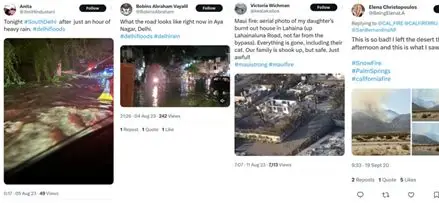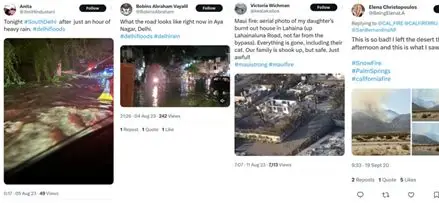


# EDA & Preprocessing : Disaster Tweets Classification

## Contexte

Ce notebook constitue la première étape du projet de classification de tweets
disaster/non-disaster, basé sur le dataset Disaster Tweets collecté le
14 janvier 2020.

---

## Objectif

L'objectif de ce notebook est de préparer les données pour la modélisation
en passant par trois grandes étapes :

* Une **analyse exploratoire (EDA)** approfondie du dataset pour comprendre
  la structure des données, les distributions, les déséquilibres et les
  caractéristiques linguistiques des tweets par classe
* Un **feature engineering** pour créer des variables numériques structurelles
  à partir du texte brut (longueur, richesse lexicale, présence d'URLs,
  de hashtags, etc.)
* Un **pipeline de nettoyage et de preprocessing** du texte pour produire
  une version exploitable par les modèles de NLP

---

## Données

Le dataset contient 11 370 tweets répartis en 5 variables :

* **id** : identifiant unique du tweet
* **keyword** : mot-clé associé au tweet 
* **location** : localisation de l'auteur 
* **text** : texte brut du tweet (variable principale)
* **target** : variable cible binaire (1 = disaster, 0 = non-disaster)

---

## Étapes du notebook

###  Chargement du dataset
* Importation des bibliotheques
###  Analyse Exploratoire (EDA)
* Distribution de la variable cible (déséquilibre 81,4% / 18,6%)
*  Détection des doublons et valeurs manquantes
* Analyse des variables `keyword` et `location`
* Distribution des features textuelles (longueur, mots, diversité lexicale)
* Analyse des n-grammes 

###  Feature Engineering
Création de 8 features numériques à partir du texte brut :
* word_count, mean_word_length, lexical_diversity
* stop_word_count, url_count, punctuation_count
* hashtag_count, keyword_disaster_rate (Target Encoding)

###  Pipeline de Nettoyage
* Mise en minuscules
* Expansion des contractions et correction des abréviations
* Suppression des URLs, mentions, emojis et caractères corrompus
* Lemmatisation via spaCy
* Tokenisation avec suppression des stopwords

###  Split Train/Test
* Division stratifiée 80/20
* Export des datasets nettoyés (`train_cleaned.csv`, `test_cleaned.csv`)

###  Résumé global

---

## Output

À la fin de ce notebook, deux fichiers CSV nettoyés et prêts pour la
modélisation seront produits :

* **train_cleaned.csv** : 9 096 tweets × 17 colonnes
* **test_cleaned.csv**  : 2 274 tweets × 17 colonnes

# **1. Chargement du dataset (Disaster Tweets)**

In [1]:
# Import des librairies 
import numpy as np # algebre lineaire
import pandas as pd # manipulation de données tabulaires (DataFrames), lecture de CSV
import matplotlib.pyplot as plt  # création de graphiques de base (courbes, histogrammes, etc.)
import seaborn as sns  # visualisation de données statistiques, basé sur matplotlib 
import string  # fournit string.punctuation : liste de tous les caractères de ponctuation
from collections import defaultdict  # dictionnaire avec valeur par défaut (évite les KeyError lors du comptage)
from collections import Counter  # compte les occurrences de chaque élément dans une liste (retourne les éléments les plus fréquents)
import nltk  # boîte à outils pour le traitement du langage naturel (NLP)
from sklearn.feature_extraction.text import CountVectorizer  # transforme du texte en matrice de comptage de mots/n-grams
import missingno as msno  # visualisation des valeurs manquantes
import re      # expressions régulières pour rechercher et remplacer des motifs dans le texte
import html    # décodage des entités HTML (&amp; → &, &lt; → <,...)
import emoji 
# Affichage du chemin d'acces au dataset dans les inputs du notebook
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Lecture du fichier et chargement en memoire dans un dataframe panda puis,
# ajustement de la taille en memoire en fonction de la taille reelle des donnees
data = pd.read_csv('/kaggle/input/datasets/vstepanenko/disaster-tweets/tweets.csv', 
                  dtype={'id': np.int16, 'target': np.int8})

# Affichage du nombre d'observations 
print('Data Shape = {}'.format(data.shape))
print('Dataset Memory Usage = {:.2f} MB'.format(data.memory_usage().sum() / 1024**2))

# Affichage des noms des variables du dataset et apercu de contenu
data.info
data.head()
data.tail()

/kaggle/input/datasets/vstepanenko/disaster-tweets/tweets.csv
Data Shape = (11370, 5)
Dataset Memory Usage = 0.29 MB


,id,keyword,location,text,target
11365,11365,wrecked,Blue State in a red sea,Media should have warned us well in advance. T...,0
11366,11366,wrecked,arohaonces,i feel directly attacked 💀 i consider moonbin ...,0
11367,11367,wrecked,🇵🇭,i feel directly attacked 💀 i consider moonbin ...,0
11368,11368,wrecked,auroraborealis,"ok who remember ""outcast"" nd the ""dora"" au?? T...",0
11369,11369,wrecked,NaN,Jake Corway wrecked while running 14th at IRP.,1


In [2]:

import nltk
nltk.data.path.append('/kaggle/input/stopwords')
from nltk.corpus import stopwords
stop = set(stopwords.words('english'))

# **2. EDA : Exploratory Data Analysis**

In [3]:
data.describe(include='all')


,id,keyword,location,text,target
count,11370.000000,11370,7952,11370,11370.000000
unique,NaN,219,4504,11223,NaN
top,NaN,thunderstorm,United States,We wanted to entertain you all with a good mov...,NaN
freq,NaN,93,96,3,NaN
mean,5684.500000,NaN,NaN,NaN,0.185928
std,3282.380615,NaN,NaN,NaN,0.389066
min,0.000000,NaN,NaN,NaN,0.000000
25%,2842.250000,NaN,NaN,NaN,0.000000
50%,5684.500000,NaN,NaN,NaN,0.000000
75%,8526.750000,NaN,NaN,NaN,0.000000


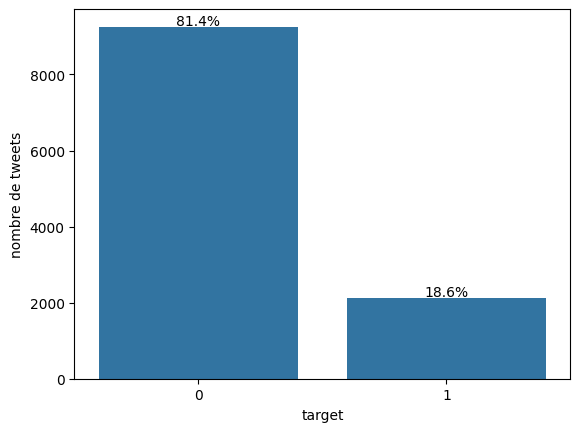

In [4]:
# Distribution du nombre de tweet selon la variable target (disaster=1 et non-disaster=0)
x = data.target.value_counts()
total = len(data)

ax = sns.barplot(x=x.index, y=x.values)
plt.gca().set_ylabel('nombre de tweets')

for i, v in enumerate(x.values):
    ax.text(i, v + 50, f'{v/total*100:.1f}%', ha='center')

plt.show()

Nous avons un déséquilibre modéré pour la variable cible avec respectivement 
81,4% de tweets non-disaster et 18,6% de tweets disaster.

## **2.1. Détection des doublons**

In [5]:
# Mise en minuscules du texte
data['text'] = data['text'].str.lower()
# Nombre de valeurs uniques pour chaque colonne
print("Valeurs uniques :")
print(data[['text', 'keyword','target','location']].nunique())

# Nombre de doublons en considérant la combinaison text + keyword
print("\nNombre de doublons (text + keyword) :")
print(data.duplicated(subset=['text', 'keyword']).sum())

Valeurs uniques :
text        11221
keyword       219
target          2
location     4504
dtype: int64

Nombre de doublons (text + keyword) :
146


In [6]:
# Apercu des doublons identifies
duplicates = data[data.duplicated(subset=['text', 'keyword'], keep=False)]
duplicates.sort_values(by=['text', 'keyword'])

,id,keyword,location,text,target
3809,3809,desolate,NaN,"""let their habitation be desolate; [and] let n...",0
3813,3813,desolate,NaN,"""let their habitation be desolate; [and] let n...",0
10635,10635,upheaval,Wiltshire - UK,"""rumours of a trial of no notice inspections""....",0
10659,10659,upheaval,NaN,"""rumours of a trial of no notice inspections""....",0
7445,7445,meltdown,NaN,"""there was a national meltdown. middle-aged wo...",0
...,...,...,...,...,...
2455,2455,collide,church + katrina❤️,you and i collide,0
4708,4708,electrocute,NaN,you electrocute our desperate daughter,0
4711,4711,electrocute,NaN,you electrocute our desperate daughter,0
4424,4424,drowned,1200-1500,you have fallen into the mill-pond and drowned,0


In [7]:
# Verifions les doublons qui presentent les memes informations de texte et keyword mais qui sont labelisees differemment pour le target
duplicates_check = duplicates.groupby(['text', 'keyword'])['target'].nunique()

# Nombre de groupes où le target est cohérent (une valeur unique pour toutes les lignes similaires) vs incohérent (deux valeurs différentes pour target sur chaque ligne possedant les memes informations de keyword et texte)
print("Groupes avec target cohérent ( valeur unique pour target) :", (duplicates_check == 1).sum())
print("Groupes avec target incohérent (2 valeurs différentes pour target) :", (duplicates_check > 1).sum())

Groupes avec target cohérent ( valeur unique pour target) : 142
Groupes avec target incohérent (2 valeurs différentes pour target) : 2


In [8]:
# Affichage des incoherences pour une verification manuelle
inconsistent = duplicates_check[duplicates_check > 1].index
data[data.set_index(['text','keyword']).index.isin(inconsistent)].sort_values(['text','keyword'])

,id,keyword,location,text,target
7640,7640,nuclear%20disaster,USA,in case of a nuclear attack to a sprawling bur...,0
7642,7642,nuclear%20disaster,God's country= The USofA,in case of a nuclear attack to a sprawling bur...,1
3737,3737,derailment,NaN,why is the 0714 hit-cam stuck at royston pleas...,1
3743,3743,derailment,UK,why is the 0714 hit-cam stuck at royston pleas...,0


In [9]:
# Cherchons combien de groupes de doublons ont 2, 3, 4... occurrences 
group_sizes = duplicates.groupby(['text','keyword']).size()
print(group_sizes.value_counts())  

2    142
3      2
Name: count, dtype: int64


**Il y a 142 doublons qui sont identiques et 2 groupes de doublons qui presentent des informations de text et keyword identique mais avec un label sur la variable target different :**
* Pour les 142 groupes de 2 occurrences : 1 ligne "originale" + 1 ligne "doublon" → 142 doublons
* Pour les 2 groupes de 3 occurrences : 1 ligne "originale" + 2 lignes "doublons" → 4 doublons
* Total : 142 + 4 = 146 doublons

**Au total, il y a 219 keywords dans le dataset et 146 lignes excédentaires que l'on doit supprimer pour ne garder qu'une seule occurrence de chaque tweet**

In [10]:
# Suppression des doublons (text + keyword identiques)
# 146 lignes supprimées
data.drop_duplicates(subset=['text', 'keyword'], keep='first', inplace=True)
data.reset_index(drop=True, inplace=True)
print(f"Nombre de lignes après suppression des doublons : {len(data)}")

Nombre de lignes après suppression des doublons : 11224


## **2.2. Valeurs manquantes**

In [11]:
print("Nombre de valeurs manquantes par colonne :")
print(data.isnull().sum())

print("\nPourcentage de valeurs manquantes par colonne :")
print((data.isnull().sum() / len(data)) * 100)

Nombre de valeurs manquantes par colonne :
id             0
keyword        0
location    3382
text           0
target         0
dtype: int64

Pourcentage de valeurs manquantes par colonne :
id           0.00000
keyword      0.00000
location    30.13186
text         0.00000
target       0.00000
dtype: float64


Dans l'ensemble du dataset, seule la variable location présente des valeurs 
manquantes avec 3382 valeurs manquantes soit 30,13% des observations.

## **2.3. Exploration de la variable location**

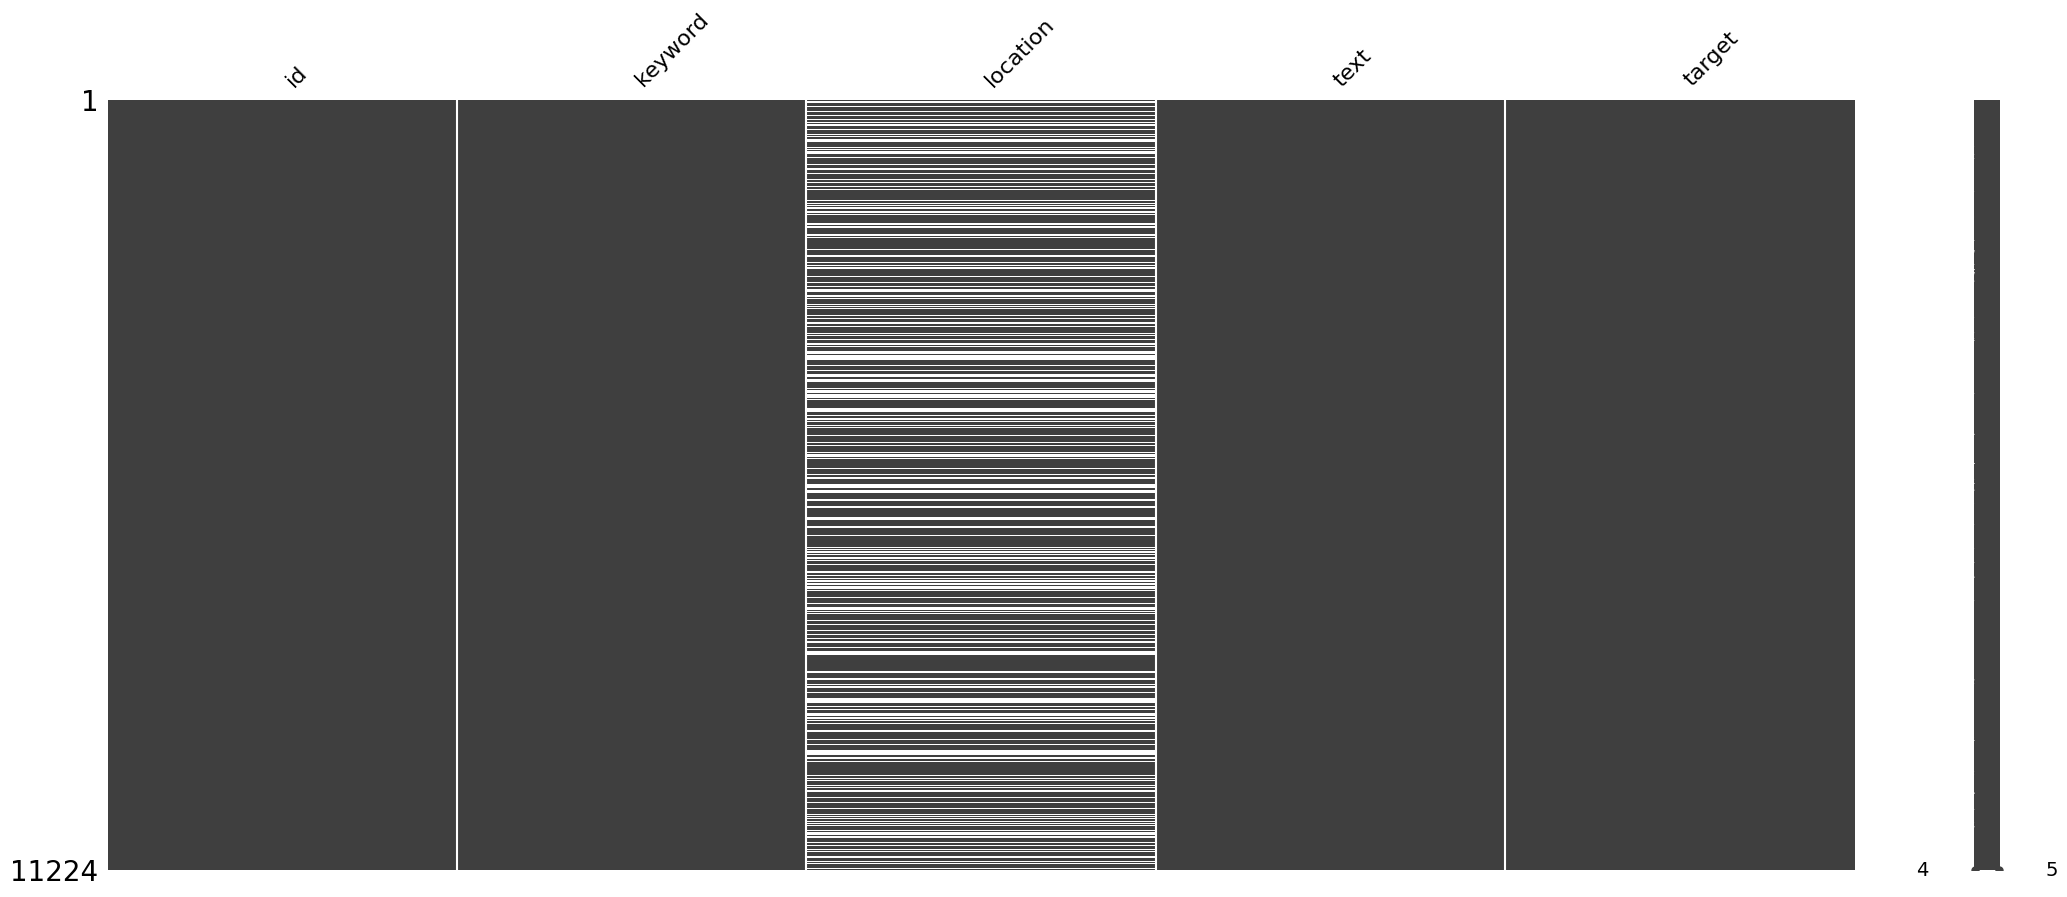

In [12]:
# Representation du nombre de valeur manquante de la variable location 
msno.matrix(data)
plt.show()

**On a 30,13% de valeurs manquantes pour la variable location**

In [13]:
# Répartition des locations renseignées (non manquantes) par target(disaster ou non-disaster)
print("Nombre de locations renseignées par target :")
print(data.groupby('target')['location'].apply(lambda x: x.notnull().sum()))

Nombre de locations renseignées par target :
target
0    6343
1    1499
Name: location, dtype: int64


**Parmi les locations renseignes, 80,88% sont labelises non-disaster contre 19,12% lablises disaster.**

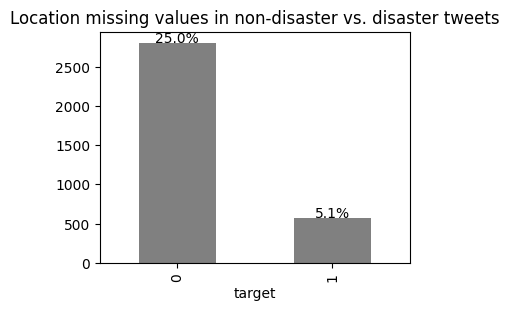

In [14]:
# Répartition des valeurs manquantes de la variable location parmi les target disaster et non-disaster
counts = data.groupby('target')['location'].apply(lambda x: x.isnull().sum())
total = len(data)

ax = counts.plot.bar(figsize=(4,3), title="Location missing values in non-disaster vs. disaster tweets", color='gray')

for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f'{v/total*100:.1f}%', ha='center')

plt.show()

**Parmi les donnees manquantes de la variable location (3382 soit 30,13%), 25,0% sont labelisees non-disaster contre 5,1% disaster**

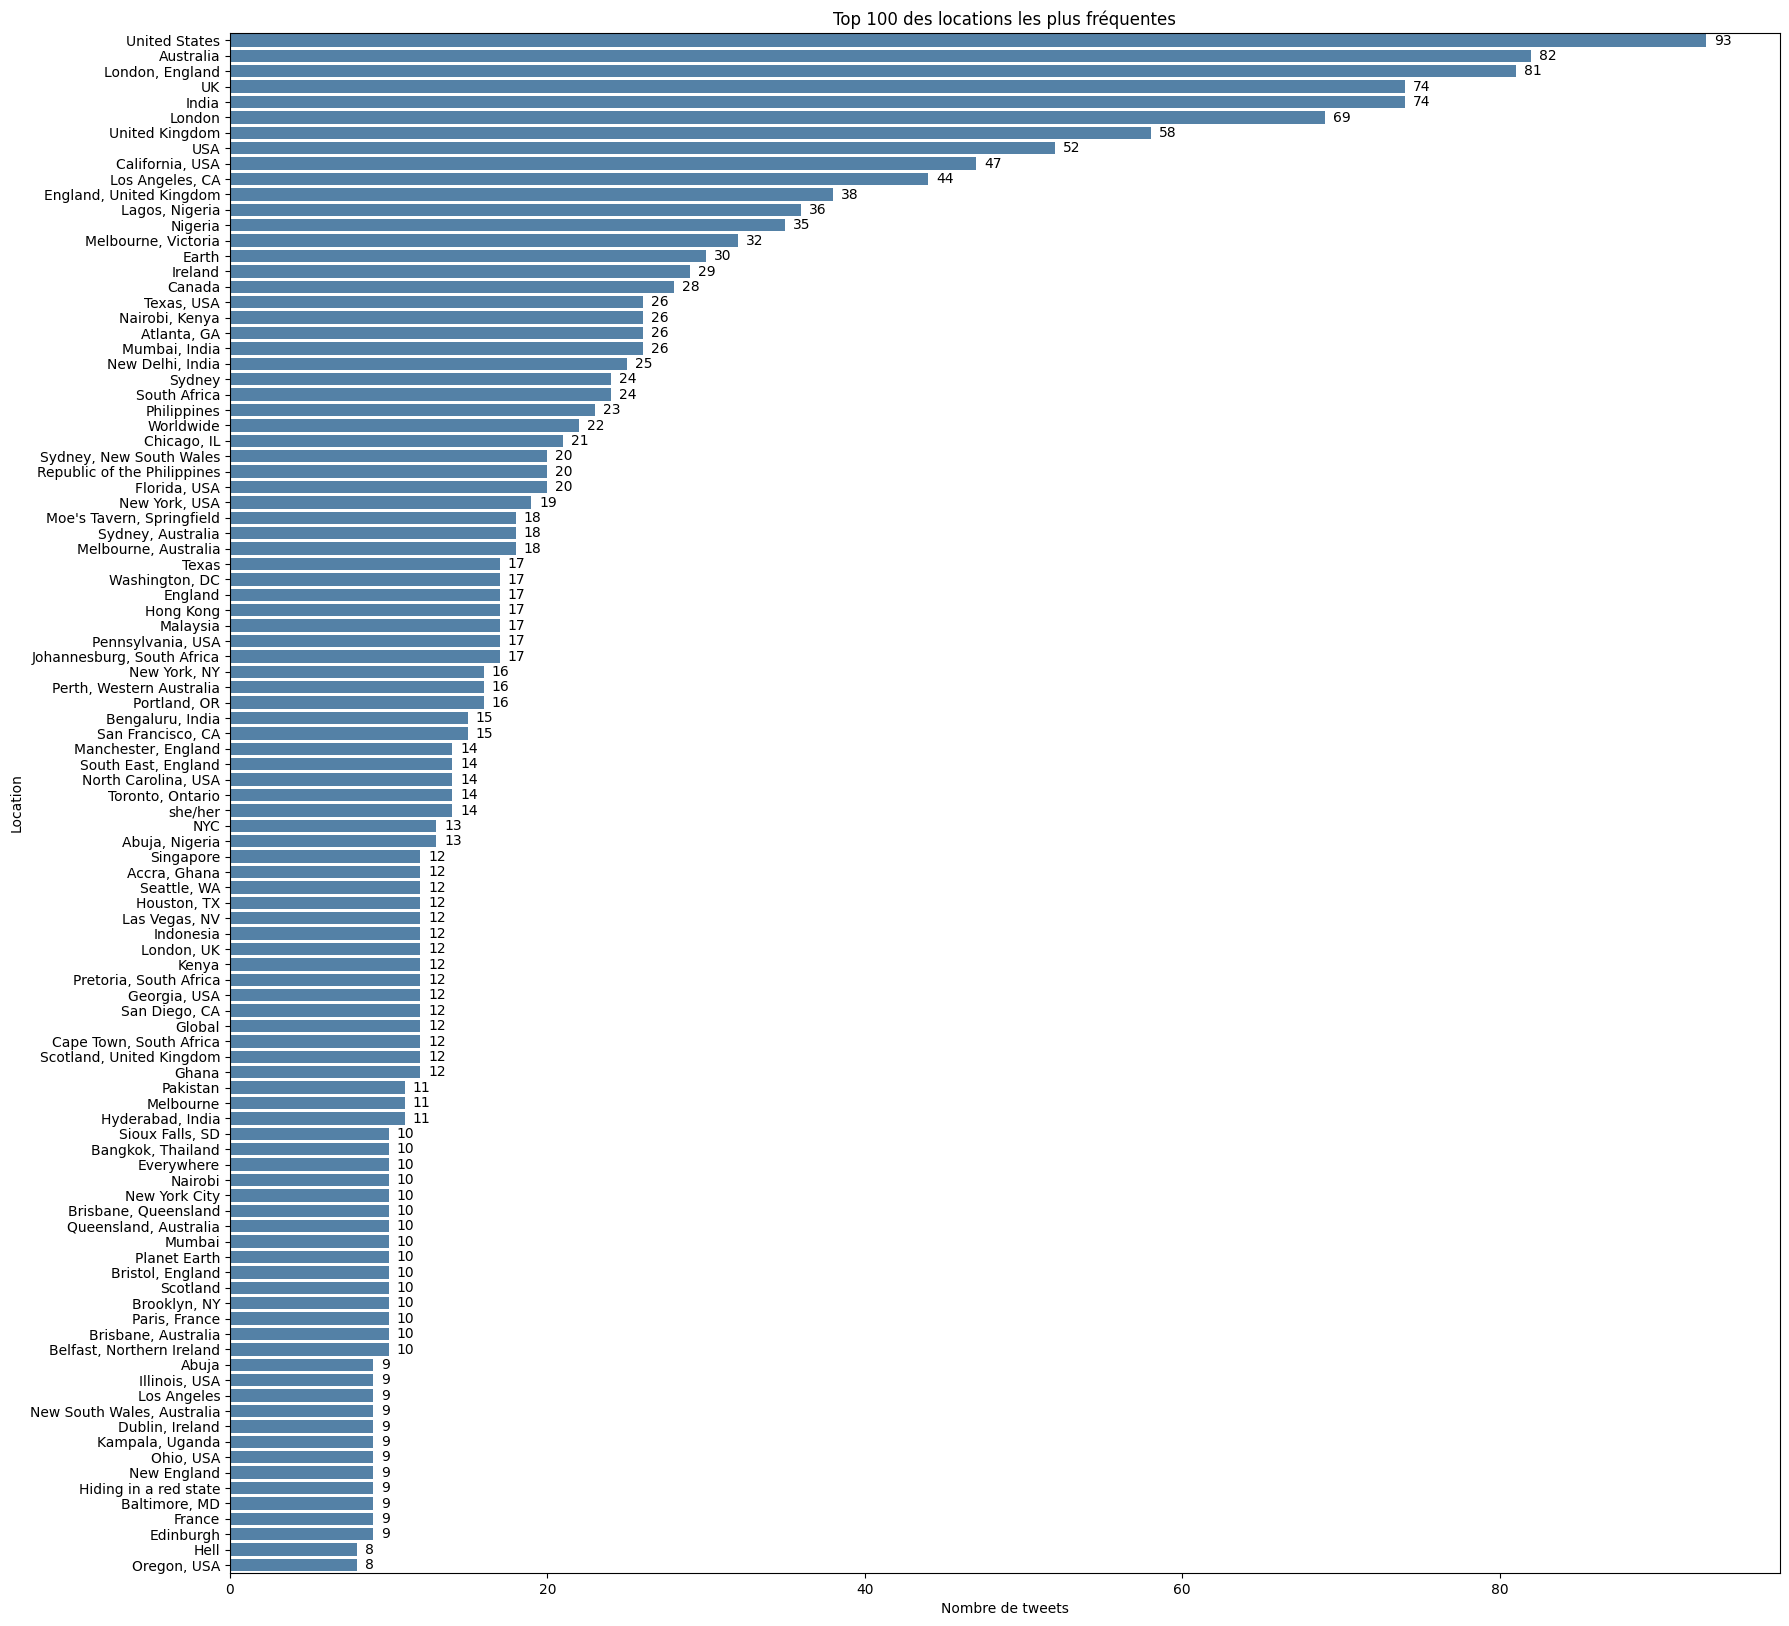

In [15]:
# Top 100 des locations les plus fréquentes (toutes les modalites de target confondues)
top_locations = data['location'].value_counts().head(100)

plt.figure(figsize=(20,20))
ax = sns.barplot(x=top_locations.values, y=top_locations.index, color='steelblue')

# Affichage des fréquences à côté de chaque barre
for i, v in enumerate(top_locations.values):
    ax.text(v + 0.5, i, str(v), va='center')

plt.title('Top 100 des locations les plus fréquentes')
plt.xlabel('Nombre de tweets')
plt.ylabel('Location')
plt.show()

**New York NY et New York USA représentent le même lieu mais sont enregistrés dans le dataset comme deux lieux différents, de même que England United Kingdom et United Kingdom, USA et United States ; certaines locations sont contenues dans d'autres comme NYC et New York NY (état et ville) ; des lieux comme she/her (qui sont des pronoms et non pas des locations), Hiding in a red state, Earth, everywhere, ... sont notés. Dans l'ensemble, la variable location a beaucoup de valeurs manquantes (30,13%), des lieux avec beaucoup d'occurrences mais dépourvues de sens ou peu précises (everywhere, earth, Planet earth, Global, she/her, Africa, ...), ce qui la rend peu exploitable pour ce projet. La variable location ne sera donc pas utilisée**


## **2.4. Exploration de la variable Keyword**

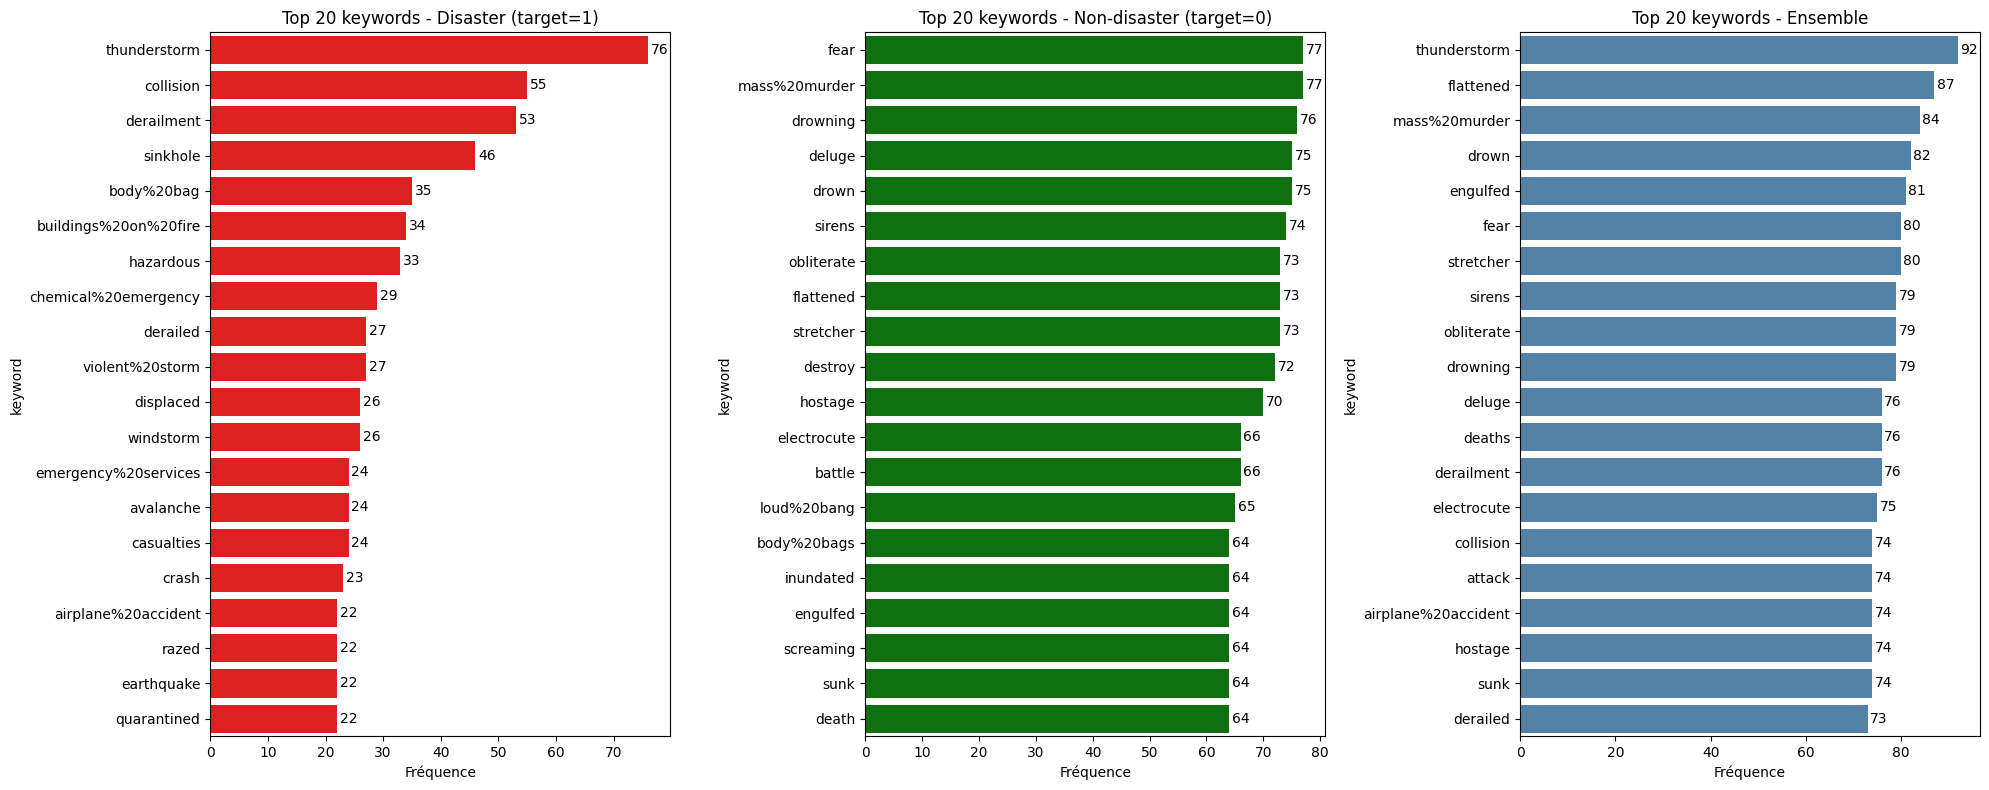

In [16]:
# Top 20 keywords les plus fréquents par classe puis pour l'ensemble

keywords_1 = data[data['target']==1]['keyword'].value_counts().head(20)
keywords_0 = data[data['target']==0]['keyword'].value_counts().head(20)
keywords_all = data['keyword'].value_counts().head(20)

fig, axes = plt.subplots(1, 3, figsize=(20,8))

# Graphique 1 : Disaster
ax1 = sns.barplot(x=keywords_1.values, y=keywords_1.index, ax=axes[0], color='red')
axes[0].set_title('Top 20 keywords - Disaster (target=1)')
axes[0].set_xlabel('Fréquence')
for i, v in enumerate(keywords_1.values):
    ax1.text(v + 0.5, i, str(v), va='center')

# Graphique 2 : Non-disaster
ax2 = sns.barplot(x=keywords_0.values, y=keywords_0.index, ax=axes[1], color='green')
axes[1].set_title('Top 20 keywords - Non-disaster (target=0)')
axes[1].set_xlabel('Fréquence')
for i, v in enumerate(keywords_0.values):
    ax2.text(v + 0.5, i, str(v), va='center')

# Graphique 3 : Ensemble
ax3 = sns.barplot(x=keywords_all.values, y=keywords_all.index, ax=axes[2], color='steelblue')
axes[2].set_title('Top 20 keywords - Ensemble')
axes[2].set_xlabel('Fréquence')
for i, v in enumerate(keywords_all.values):
    ax3.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()

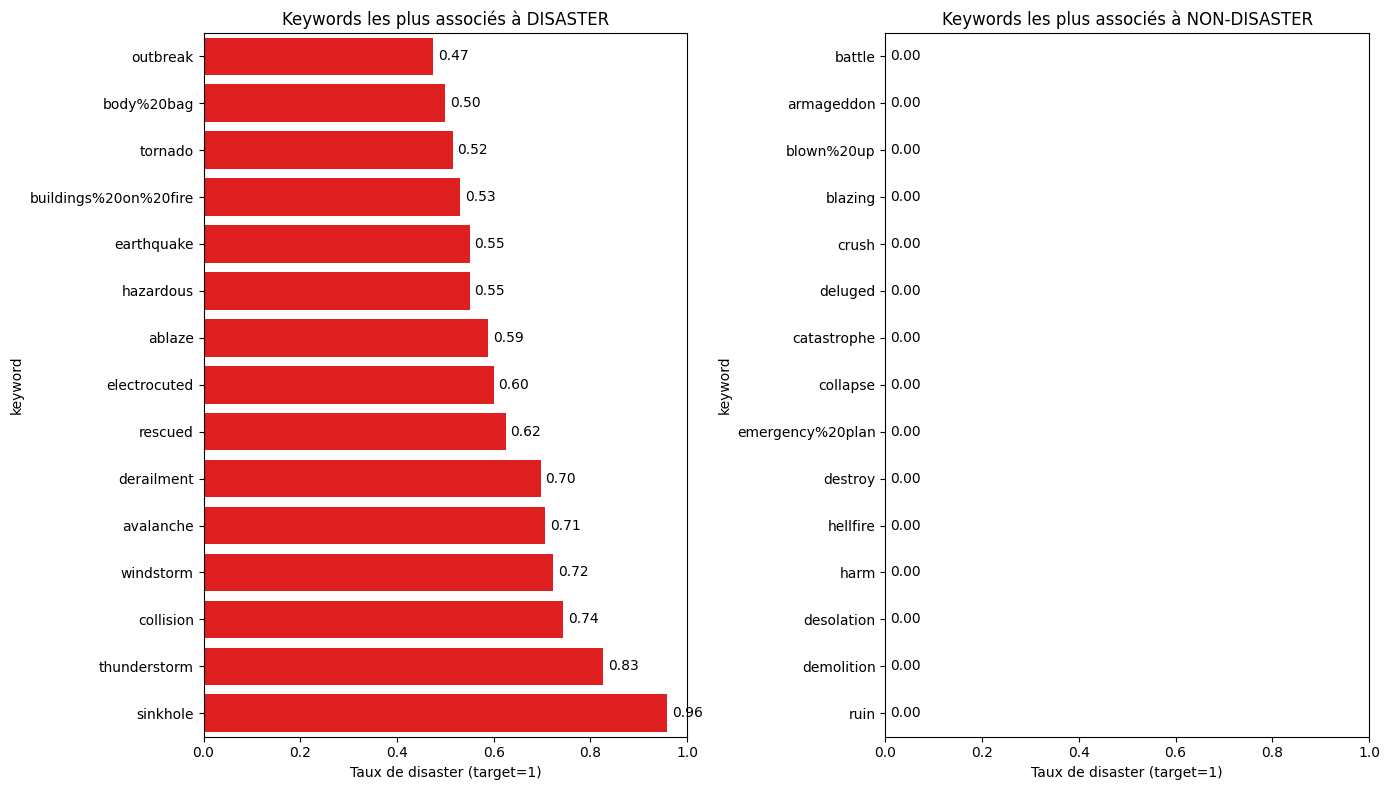

In [17]:
# Calcul du taux de disaster pour chaque keyword(nombre d'occurrence de tweet disaster pour chaque keyword sur le nombre total d'occurrence du keyword )
keyword_ratio = data.groupby('keyword')['target'].agg(['mean', 'count'])
keyword_ratio.columns = ['disaster_rate', 'total_count']

# On ne garde que les keywords avec un minimum d'occurrences (superieur a 5 pour la fiabilité)
keyword_ratio = keyword_ratio[keyword_ratio['total_count'] >= 5]

# Tri par taux de disaster (les taux les plus eleves signifiennt que qu'il ya beaucoup plus de disaster tweet pour un keyword que de non-disaster tweet)
# Ceci va permettre de faire ressortir avec .head() et .tail() les keywords possedant respectivement plus d'occurrences disaster et plus d'occurrences non-disaster
keyword_ratio_sorted = keyword_ratio.sort_values('disaster_rate')


# Top 15 keywords les plus associés à Disaster (taux plus eleve donc proche de 1)
top_disaster = keyword_ratio_sorted.tail(15)

# Top 15 keywords les plus associés à Non-disaster (taux plus bas donc proche de 0)
top_non_disaster = keyword_ratio_sorted.head(15)


fig, axes = plt.subplots(1, 2, figsize=(14,8))

ax1 = sns.barplot(x=top_disaster['disaster_rate'].values, y=top_disaster.index, ax=axes[0], color='red')
axes[0].set_title('Keywords les plus associés à DISASTER')
axes[0].set_xlabel('Taux de disaster (target=1)')
axes[0].set_xlim(0,1)
for i, v in enumerate(top_disaster['disaster_rate'].values):
    ax1.text(v + 0.01, i, f'{v:.2f}', va='center')

ax2 = sns.barplot(x=top_non_disaster['disaster_rate'].values, y=top_non_disaster.index, ax=axes[1], color='green')
axes[1].set_title('Keywords les plus associés à NON-DISASTER')
axes[1].set_xlabel('Taux de disaster (target=1)')
axes[1].set_xlim(0,1)
for i, v in enumerate(top_non_disaster['disaster_rate'].values):
    ax2.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

* disaster_rate = 0.0 → tous les tweets avec ce keyword ont un target = 0 → ce keyword n'est jamais associé à un vrai disaster → c'est un keyword non-disaster.
* disaster_rate = 1.0 → tous les tweets avec ce keyword ont un target = 1 → ce keyword est toujours associé à un vrai disaster → c'est un keyword disaster.

* disaster_rate = 0.5 → keyword ambigu donc on ne peut pas trancher

In [18]:
# Regardons de plus pres les keywords ayant des taux nuls pour voir les occurrences de non-disaster pour ces keywords (est ce important ou non)
print("Keywords avec taux = 0.0 :", (keyword_ratio['disaster_rate'] == 0).sum())
print("Keywords avec taux = 1.0 :", (keyword_ratio['disaster_rate'] == 1).sum())
print(keyword_ratio_sorted.head(20))

Keywords avec taux = 0.0 : 18
Keywords avec taux = 1.0 : 0
                  disaster_rate  total_count
keyword                                     
battle                 0.000000           66
armageddon             0.000000           26
blown%20up             0.000000           17
blazing                0.000000           60
crush                  0.000000           43
deluged                0.000000           10
catastrophe            0.000000           25
collapse               0.000000           59
emergency%20plan       0.000000           25
destroy                0.000000           72
hellfire               0.000000           51
harm                   0.000000           61
desolation             0.000000           20
demolition             0.000000           60
ruin                   0.000000           47
mayhem                 0.000000           44
twister                0.000000           18
siren                  0.000000           10
deluge                 0.013158          

In [19]:
# Regardons aussi les occurrences de tweet disaster pour les keywords avec les taux les plus eleves
print(keyword_ratio_sorted.tail(20))

                       disaster_rate  total_count
keyword                                          
quarantined                 0.431373           51
casualties                  0.436364           55
chemical%20emergency        0.439394           66
rubble                      0.441176           34
injured                     0.454545           44
outbreak                    0.475000           40
body%20bag                  0.500000           70
tornado                     0.515152           33
buildings%20on%20fire       0.531250           64
earthquake                  0.550000           40
hazardous                   0.550000           60
ablaze                      0.588235           34
electrocuted                0.600000           15
rescued                     0.625000           32
derailment                  0.697368           76
avalanche                   0.705882           34
windstorm                   0.722222           36
collision                   0.743243           74


L'analyse du taux de disaster par keyword révèle des taux allant de 0% à 95,83%, ce qui montre que cette variable permet de bien discerner certains keywords associes a un disaster  :
*  À une extrémité, 18 keywords présentent un taux de 0% (ex : "armageddon", "catastrophe", "destroy", "hellfire"), montrant qu'ils sont systématiquement employés au sens figuré ou dans un sens non catastrophique dans ce dataset.
*  À l'autre extrémité, des keywords comme "sinkhole" (95,83%), "thunderstorm" (82,6%) ou "collision" (74,32%) sont fortement associés à de véritables disasters.
*  Une zone intermédiaire (taux proches de 0,5) regroupe des keywords plus ambigus, dont le contexte au sein du tweet sera déterminant.
Cette repartition confirme que le keyword constitue une feature exploitable et potentiellement informative pour la classification.

In [20]:
# Keywords présents à la fois dans les tweets disaster et non-disaster
keywords_disaster = set(data[data['target']==1]['keyword'].dropna().unique())
keywords_non_disaster = set(data[data['target']==0]['keyword'].dropna().unique())

common_keywords = keywords_disaster.intersection(keywords_non_disaster)

print(f"Nombre de keywords communs : {len(common_keywords)}")
print(common_keywords)

Nombre de keywords communs : 201
{'bloody', 'debris', 'army', 'accident', 'bridge%20collapse', 'hijacking', 'eyewitness', 'attacked', 'survived', 'chemical%20emergency', 'smoke', 'fatal', 'famine', 'trouble', 'casualties', 'lava', 'hail', 'ambulance', 'avalanche', 'hijack', 'blood', 'hailstorm', 'razed', 'first%20responders', 'injury', 'thunderstorm', 'rubble', 'fear', 'wounds', 'deaths', 'collision', 'hazardous', 'mudslide', 'obliterated', 'aftershock', 'hazard', 'military', 'refugees', 'airplane%20accident', 'sinkhole', 'wreck', 'forest%20fires', 'burned', 'cliff%20fall', 'inundated', 'inundation', 'seismic', 'rescued', 'tragedy', 'landslide', 'curfew', 'bombed', 'displaced', 'cyclone', 'panic', 'rioting', 'emergency%20services', 'snowstorm', 'body%20bags', 'dead', 'stretcher', 'suicide%20bomber', 'police', 'traumatised', 'volcano', 'windstorm', 'electrocuted', 'hostage', 'sirens', 'hijacker', 'forest%20fire', 'earthquake', 'collided', 'derail', 'heat%20wave', 'hurricane', 'body%20ba

**Au total, 201 keywords présents dans les tweets disaster sont aussi présents 
dans les tweets non-disaster, soit 91,78% de l'ensemble des keywords du dataset. 
Cependant, l'analyse du taux de disaster par keyword révèle une répartition 
souvent très déséquilibrée au sein de ces keywords communs (certains ayant un 
taux proche de 0 et d'autres proche de 1). Ce déséquilibre démontre le pouvoir 
discriminant du keyword malgré sa présence dans les deux classes, ce qui en fait 
une feature pertinente à conserver pour ce projet.**

## 2.5. Création de nouvelles variables

Nous allons créer de nouveaux features :
* word_count: nombre de mots dans le texte
* mean_word_length: longueur moyenne des mots (en nombre de caractères)
* lexical_diversity : ratio entre le nombre de mots uniques dans un tweet et le nombre total de mots
* stop_word_count: nombre de mots de liaison (comme is, the, a,...) dans le texte
* url_count: nombre d'URLs dans le texte
* punctuation_count: nombre de signes de ponctuation dans le texte
* hashtag_count: nombre de hashtags (#) dans le texte
* Keyword_disaster_rate qui va etre créee uniquement apres le split pour éviter un data-leakage.

In [21]:
# Variable word_count qui compte le nombre de mots dans le texte d'un tweet
# Par défaut le split se fait en repérant les espaces, sauts de ligne et tabulations entre mots
data['word_count'] = data['text'].apply(lambda x: len(x.split()))

# Affichage filtre par target(disaster=1 or no disaster=0)
print('statistique descriptive')
print(data.groupby("target")["word_count"].describe())

statistique descriptive
         count       mean       std  min   25%   50%   75%   max
target                                                          
0       9151.0  17.174189  5.678839  1.0  14.0  19.0  21.0  32.0
1       2073.0  17.450072  4.562579  1.0  15.0  19.0  21.0  29.0


Les statistiques descriptives du word_count révèlent des distributions très 
similaires entre les deux classes, avec des moyennes quasi identiques (17,17 
vs 17,45) et des quartiles quasi-identiques. La principale différence réside dans l'écart-type (5,67 vs 4,56), confirmant que les tweets non-disaster sont plus variables en nombre de mots. Le word_count seul a donc un pouvoir discriminant limité ; c'est sa combinaison avec d'autres features (hashtag_count, url_count, contenu textuel) qui sera déterminante pour la classification.

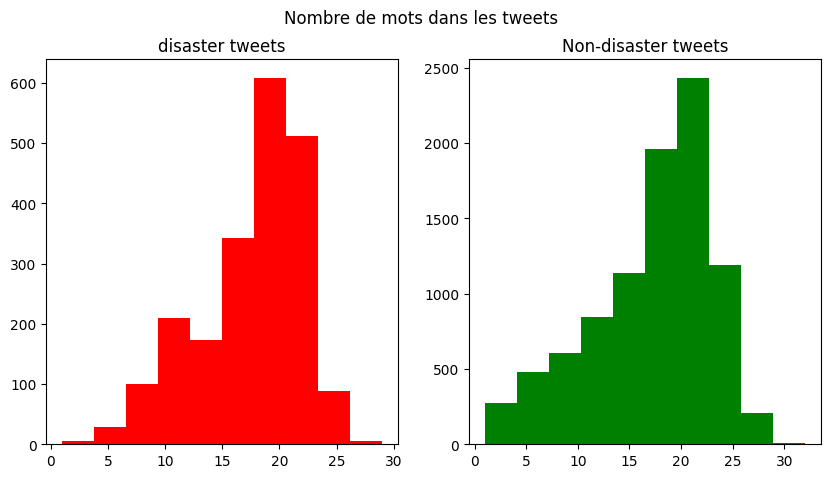

Skewness (asymétrie) :
target
0   -0.736075
1   -0.686660
Name: word_count, dtype: float64

Kurtosis (aplatissement) :
target
0   -0.156007
1   -0.031854
Name: word_count, dtype: float64


In [22]:
# Distribution (graphique) par nombre de mots dans les tweets (variable word_count) et par classe (disaster ou non-disaster)

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(data[data['target']==1]['word_count'],color='red')
ax1.set_title('disaster tweets')
ax2.hist(data[data['target']==0]['word_count'],color='green')
ax2.set_title('Non-disaster tweets')
fig.suptitle('Nombre de mots dans les tweets')
plt.show()

# Asymétrie (skewness) et aplatissement (kurtosis) de word_count
print("Skewness (asymétrie) :")
print(data.groupby('target')['word_count'].skew())

print("\nKurtosis (aplatissement) :")
print(data.groupby('target')['word_count'].apply(lambda x: x.kurtosis()))

Les deux classes présentent des distributions similaires en termes de forme 
(asymétrie négative et légèrement aplaties), mais avec quelques différences :
* Les tweets disaster ont une asymétrie légèrement moins prononcée (-0,687 vs 
  -0,736) et un kurtosis plus élevé (-0,156 vs -0,032), indiquant 
  une distribution plus concentrée et homogène autour du pic (15-25 mots).
* Les tweets non-disaster sont plus étalés et plus variables, avec une queue 
  a gauche légèrement plus prononcée (il y a davantage de tweets courts).

Ces différences, bien que subtiles, confirment que le word_count apporte une 
information discriminante entre les deux classes.

In [23]:
# Création d'une variable temporaire de texte partiellement nettoyé (suppression 
# des URLs, hashtags, mentions et séparateurs typographiques) uniquement pour 
# le calcul de mean_word_length. En effet, split() fait le decoupage des mots grace aux espaces et 
# considère donc ces éléments comme des mots à part entière, créant des outliers 
# (ex: "http://t.co/xyz" compté comme 1 mot de 15 caractères).
# Cette variable temporaire sera supprimée après le calcul.
import re
import html

def clean_for_mean_word_length(text):
    # 1. Décoder les entités HTML (&amp; → &, &lt; → <)
    text = html.unescape(text)
    # 2. Supprimer les URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Supprimer les hashtags (le # et le mot collé)
    text = re.sub(r'#\w+', '', text)
    # 4. Supprimer les mentions (@)
    text = re.sub(r'@\w+', '', text)
    # 5. Supprimer les séparateurs (suites de tirets, points,...)
    text = re.sub(r'[-_.]{2,}', ' ', text)
    # 6. Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# calcul de mean_word_length sur texte partiellement nettoyé
data['mean_word_length'] = data['text'].apply(clean_for_mean_word_length).apply(
    lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
)

In [24]:

# Affichage filtre par target(disaster=1 or no disaster=0)
print('statistique descriptive')
print(data.groupby("target")["mean_word_length"].describe())

statistique descriptive
         count      mean       std  min       25%       50%       75%   max
target                                                                     
0       9151.0  4.719376  0.866898  0.0  4.166667  4.600000  5.142857  17.5
1       2073.0  5.009349  0.734924  0.0  4.523810  4.928571  5.428571   9.0


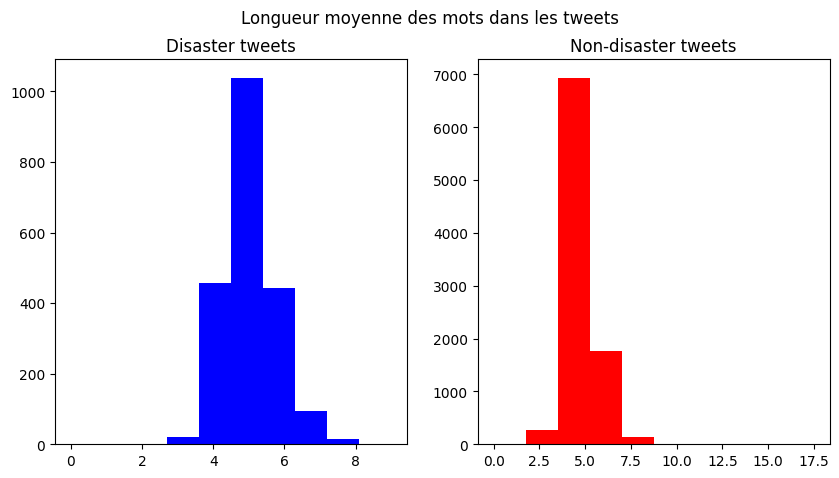

Skewness (asymétrie) :
target
0    2.007701
1    0.581712
Name: mean_word_length, dtype: float64

Kurtosis (aplatissement) :
target
0    15.108338
1     2.193094
Name: mean_word_length, dtype: float64


In [25]:
# Distribution de la longueur moyenne des mots par classe
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(data[data['target']==1]['mean_word_length'],color='blue')
ax1.set_title('Disaster tweets')
ax2.hist(data[data['target']==0]['mean_word_length'],color='red')
ax2.set_title('Non-disaster tweets')
fig.suptitle('Longueur moyenne des mots dans les tweets')
plt.show()

# Skewness et kurtosis
print("Skewness (asymétrie) :")
print(data.groupby('target')['mean_word_length'].skew())
print("\nKurtosis (aplatissement) :")
print(data.groupby('target')['mean_word_length'].apply(lambda x: x.kurtosis()))

Le mean_word_length révèle une différence notable entre les deux classes :
Les tweets disaster présentent une distribution régulière et symétrique (skew = 0,582, kurtosis = 2,193), concentrée entre 4 et 6 caractères par mot, reflétant un vocabulaire homogène (ex: "earthquake","casualties","derailment").

Les tweets non-disaster présentent une distribution beaucoup plus asymétrique (skew = 1,995) avec un kurtosis très élevé (15,108), indiquant un pic très pointu vers 3-5 caractères avec une queue droite prononcée (valeurs jusqu'à 17,5). Cela reflète un langage conversationnel majoritairement composé de mots courts, avec quelques cas isolés de mots très longs.

Combinées aux statistiques descriptives (moyenne 5 vs 4,71 ; std 0,73 vs 
0,86), ces différences de forme confirment que mean_word_length constitue 
une feature discriminante : les tweets disaster ont un vocabulaire plus long, 
plus homogène et plus structuré que les tweets non-disaster.

In [26]:
# Diversité lexicale : ratio entre le nombre de mots uniques et le nombre total de mots
# (unique_word_count supprimé car corrélation de 0.97 avec word_count)
data['lexical_diversity'] = data['text'].apply(
    lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0
)

# Affichage filtre par target(disaster=1 or no disaster=0)
print('statistique descriptive')
print(data.groupby("target")["lexical_diversity"].describe())

statistique descriptive
         count      mean       std       min       25%       50%  75%  max
target                                                                    
0       9151.0  0.950879  0.063084  0.217391  0.916667  0.956522  1.0  1.0
1       2073.0  0.956981  0.053069  0.631579  0.933333  0.960000  1.0  1.0


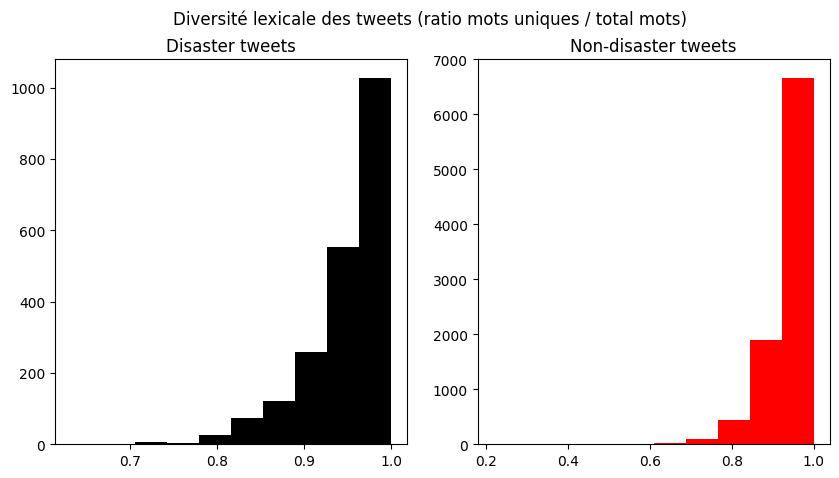

Skewness (asymétrie) :
target
0   -1.946413
1   -1.283076
Name: lexical_diversity, dtype: float64

Kurtosis (aplatissement) :
target
0    7.774525
1    1.674268
Name: lexical_diversity, dtype: float64


In [27]:
# Distribution (graphique) de la diversité lexicale (lexical_diversity) par classe (disaster ou non-disaster)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(data[data['target']==1]['lexical_diversity'],color='black')
ax1.set_title('Disaster tweets')
ax2.hist(data[data['target']==0]['lexical_diversity'],color='red')
ax2.set_title('Non-disaster tweets')
fig.suptitle('Diversité lexicale des tweets (ratio mots uniques / total mots)')
plt.show()

# Asymétrie (skewness) et aplatissement (kurtosis) de la diversité lexicale
print("Skewness (asymétrie) :")
print(data.groupby('target')['lexical_diversity'].skew())
print("\nKurtosis (aplatissement) :")
print(data.groupby('target')['lexical_diversity'].apply(lambda x: x.kurtosis()))

La lexical_diversity révèle une différence notable entre les deux classes :
* Les tweets disaster sont très concentrés vers une diversité lexicale élevée 
  (0,9 - 1,0), avec peu de répétitions de mots (skew = -1,28 ; kurtosis = 1,67). Cela reflète l'usage d'un vocabulaire beaucoup plus diverse pour décrire un événement.
* Les tweets non-disaster présentent aussi un pic vers 1,0 mais avec une queue 
  gauche beaucoup plus prononcée (valeurs jusqu'à 0,2) et un kurtosis très élevé (7,77), indiquant la présence de tweets très répétitifs (par exemple une répétition de mots pour mettre l'accent sur une information).
Cette différence de distribution confirme que la lexical_diversity est une 
feature discriminante utile : une faible diversité lexicale est quasi-exclusivement associée aux tweets non-disaster.

In [28]:
# Nombre de stopwords dans le texte brut
# Les stopwords sont des mots courants comme the, a, in, is,...
data['stop_word_count'] = data['text'].apply(
    lambda x: len([word for word in x.lower().split() if word in stop])
)

# Affichage filtre par target(disaster=1 or no disaster=0)
print('statistique descriptive')
print(data.groupby("target")["stop_word_count"].describe())

statistique descriptive
         count      mean       std  min  25%  50%  75%   max
target                                                      
0       9151.0  6.405748  3.457477  0.0  4.0  6.0  9.0  21.0
1       2073.0  5.518572  3.094828  0.0  3.0  5.0  8.0  16.0


Les tweets non-disaster contiennent en moyenne plus de stopwords (6,41 vs 5,51) que les tweets disaster. Cela s'explique par le fait que les tweets disaster utilisent certainement un langage condensé (moins de mots de liaison), tandis que les tweets non-disaster emploient un langage plus conversationnel et donc naturellement plus riche en stopwords (the, a, in, is, etc.).
Cette différence suggère que stop_word_count est une feature potentiellement 
discriminante : un nombre élevé de stopwords tend à être associé aux tweets 
non-disaster.

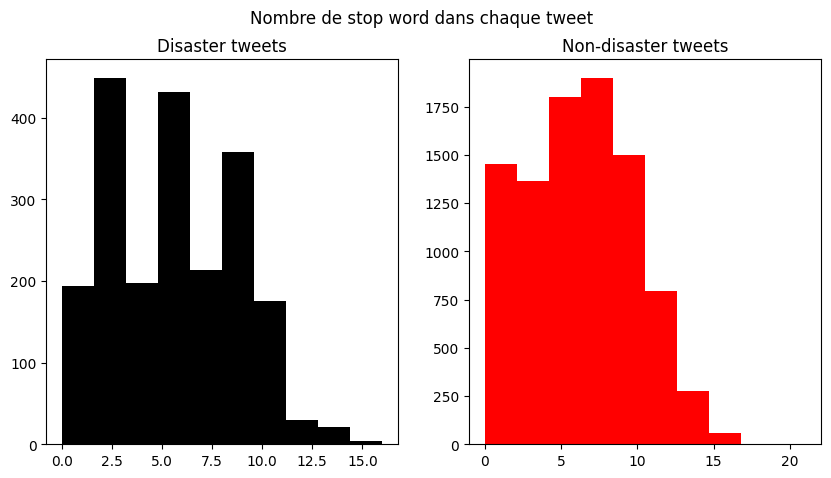

Skewness (asymétrie) :
target
0    0.091143
1    0.280184
Name: stop_word_count, dtype: float64

Kurtosis (aplatissement) :
target
0   -0.583501
1   -0.588420
Name: stop_word_count, dtype: float64


In [29]:
# Distribution (graphique) du nombre de stop word (stop_word_count) par classe (disaster ou non-disaster)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(data[data['target']==1]['stop_word_count'],color='black')
ax1.set_title('Disaster tweets')
ax2.hist(data[data['target']==0]['stop_word_count'],color='red')
ax2.set_title('Non-disaster tweets')
fig.suptitle('Nombre de stop word dans chaque tweet')
plt.show()

# Asymétrie (skewness) et aplatissement (kurtosis) de stop_word_count
print("Skewness (asymétrie) :")
print(data.groupby('target')['stop_word_count'].skew())
print("\nKurtosis (aplatissement) :")
print(data.groupby('target')['stop_word_count'].apply(lambda x: x.kurtosis()))

Le stop_word_count présente des distributions asymétriques à droite pour les 
deux classes (skew = +0,091 pour non-disaster et +0,280 pour disaster), avec 
des kurtosis négatifs indiquant des distributions légèrement aplaties.

La distribution des tweets disaster est notable par sa forme multimodale 
(plusieurs pics distincts vers 2-3, 5-6 et 8 stopwords), suggérant l'existence 
de sous-groupes de tweets disaster avec des structures différentes (tweets très courts et factuels vs tweets plus développés avec un contexte explicite).

Les tweets non-disaster présentent une distribution plus régulière et plus 
symétrique, centrée entre 5 et 8 stopwords, cohérente avec un langage plus 
conversationnel et homogène.

Confirmant les statistiques descriptives, le stop_word_count constitue une 
feature discriminante : les tweets disaster tendent à utiliser moins de 
stopwords (langage factuel et condensé) avec une plus grande variabilité.

In [30]:
import re  # expressions régulières pour rechercher des motifs dans le texte (URLs, mentions, hashtags...)

# Nombre d'URLs dans le texte brut 
data['url_count'] = data['text'].apply(
    lambda x: len(re.findall(r'http\S+|www\S+', x))
)

# Statistiques descriptives du url_count par classe
print('statistique descriptive')
print(data.groupby("target")["url_count"].describe())


statistique descriptive
         count      mean       std  min  25%  50%  75%  max
target                                                     
0       9151.0  0.487816  0.540228  0.0  0.0  0.0  1.0  3.0
1       2073.0  0.603473  0.581261  0.0  0.0  1.0  1.0  3.0


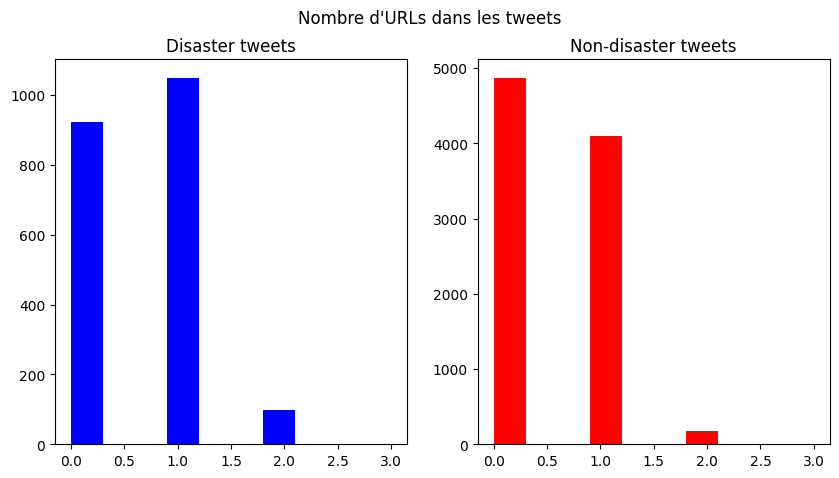

Skewness (asymétrie) :
target
0    0.472683
1    0.359187
Name: url_count, dtype: float64

Kurtosis (aplatissement) :
target
0   -0.809516
1   -0.638685
Name: url_count, dtype: float64


In [31]:
# Distribution par classe
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(data[data['target']==1]['url_count'],color='blue')
ax1.set_title('Disaster tweets')
ax2.hist(data[data['target']==0]['url_count'],color='red')
ax2.set_title('Non-disaster tweets')
fig.suptitle("Nombre d'URLs dans les tweets")
plt.show()

# Skewness et kurtosis
print("Skewness (asymétrie) :")
print(data.groupby('target')['url_count'].skew())
print("\nKurtosis (aplatissement) :")
print(data.groupby('target')['url_count'].apply(lambda x: x.kurtosis()))

Le url_count révèle une différence notable entre les deux classes : les tweets 
disaster contiennent en moyenne plus d'URLs (0,603 vs 0,487) et ont une médiane de 1 (contre 0 pour les non-disaster). Cela suggère que les tweets relatant de vraies catastrophes partagent plus fréquemment des liens vers des sources d'information (articles, rapports, images), tandis que les tweets non-disaster sont plus souvent des réactions spontanées sans lien externe.

Cette différence fait du url_count une feature potentiellement discriminante 
pour la classification.

In [32]:
# Nombre de signes de ponctuation dans le texte brut
data['punctuation_count'] = data['text'].apply(
    lambda x: len([c for c in x if c in string.punctuation])
)

# Statistiques descriptives du punctuation_count par classe
print('statistique descriptive')
print(data.groupby("target")["punctuation_count"].describe())

statistique descriptive
         count      mean       std  min  25%  50%  75%   max
target                                                      
0       9151.0  5.127418  3.754188  0.0  2.0  5.0  7.0  49.0
1       2073.0  5.521466  3.259623  0.0  3.0  6.0  8.0  25.0


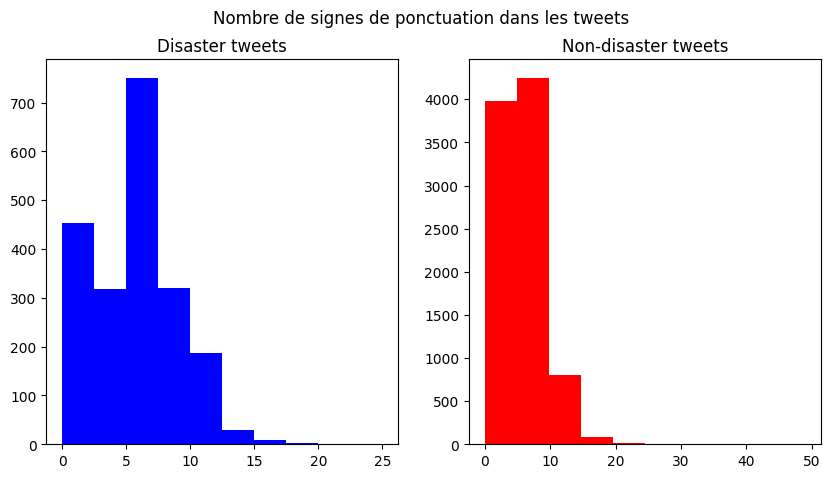

Skewness (asymétrie) :
target
0    1.681653
1    0.507758
Name: punctuation_count, dtype: float64

Kurtosis (aplatissement) :
target
0    11.346278
1     0.692388
Name: punctuation_count, dtype: float64


In [33]:
# Distribution par classe
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(data[data['target']==1]['punctuation_count'],color='blue')
ax1.set_title('Disaster tweets')
ax2.hist(data[data['target']==0]['punctuation_count'],color='red')
ax2.set_title('Non-disaster tweets')
fig.suptitle("Nombre de signes de ponctuation dans les tweets")
plt.show()

# Skewness et kurtosis
print("Skewness (asymétrie) :")
print(data.groupby('target')['punctuation_count'].skew())
print("\nKurtosis (aplatissement) :")
print(data.groupby('target')['punctuation_count'].apply(lambda x: x.kurtosis()))

In [34]:
# Identifier les tweets avec beaucoup trop de ponctuation
data[data['punctuation_count'] > 20][['text', 'punctuation_count', 'target']]

,text,punctuation_count,target
171,"besides the airplane being shot down by ""accid...",23,0
975,it wont taste the same and like i’d...... die....,27,0
1262,"""...bloody maury"" ""...bloody maury"" ""...bloody...",24,0
1396,tuesday headlines.....stormont power back on.....,21,0
1405,tuesday headlines.....stormont power back on.....,26,0
1519,---------- oct 2033 ---------- united states o...,25,1
1538,---------- sep 2033 ---------- united states o...,25,0
1553,---------- aug 2033 ---------- united states o...,25,0
1564,nato...bombed...libya...statehood...russia...f...,41,0
2011,search...rescue...mission...airlift...military...,38,0


La variable punctuation_count révèle que les tweets disaster contiennent légèrement plus de signes de ponctuation en moyenne (5,52 vs 5,12), avec une distribution plus régulière et symétrique (skew = 0,5 ; kurtosis = 0,69).

Les tweets non-disaster présentent une distribution beaucoup plus asymétrique 
(skew = 1,68) avec un kurtosis très élevé (11,34), indiquant la présence de 
valeurs élevées (max = 49) correspondant à des tweets contenant beaucoup de séparateurs (suites de tirets type "---------- Aug 2033 ---------- United States " ou ""...Bloody Maury" "...Bloody Maury" "...B"). Ces caractéristiques étant inhérentes au contenu réel des tweets et pouvant constituer une information discriminante, elles sont conservées telles quelles.

Dans l'ensemble, le punctuation_count constitue une feature discriminante utile : les tweets disaster ont une ponctuation plus homogène et légèrement plus élevée, reflétant un style d'écriture plus structuré et factuel.

statistique descriptive - hashtag_count
         count      mean       std  min  25%  50%  75%   max
target                                                      
0       9151.0  0.208393  0.704986  0.0  0.0  0.0  0.0  11.0
1       2073.0  0.325133  0.815765  0.0  0.0  0.0  0.0   7.0


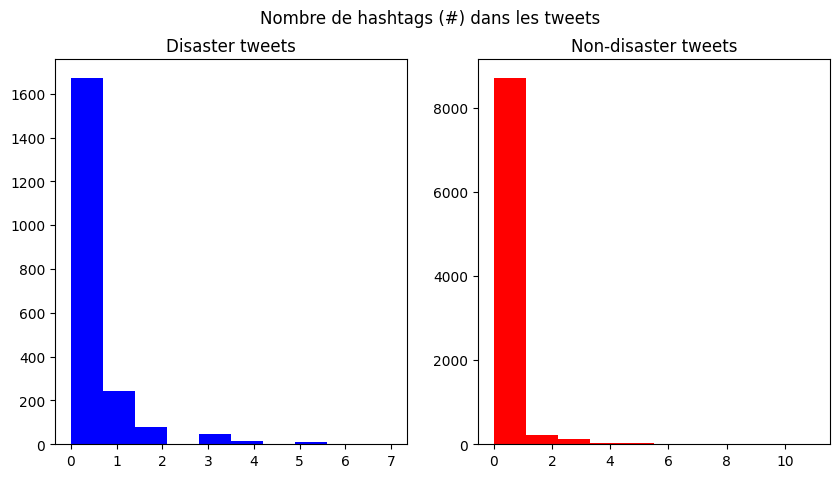

Skewness (asymétrie) :
target
0    5.013316
1    3.333340
Name: hashtag_count, dtype: float64

Kurtosis (aplatissement) :
target
0    34.218746
1    13.369073
Name: hashtag_count, dtype: float64


In [35]:
# Nombre de hashtags (#) dans le texte brut (avant nettoyage)
data['hashtag_count'] = data['text'].apply(
    lambda x: len(re.findall(r'#\w+', x))
)

# Statistiques descriptives par classe
print('statistique descriptive - hashtag_count')
print(data.groupby("target")["hashtag_count"].describe())

# Distribution par classe
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.hist(data[data['target']==1]['hashtag_count'],color='blue')
ax1.set_title('Disaster tweets')
ax2.hist(data[data['target']==0]['hashtag_count'],color='red')
ax2.set_title('Non-disaster tweets')
fig.suptitle("Nombre de hashtags (#) dans les tweets")
plt.show()

# Skewness et Kurtosis
print("Skewness (asymétrie) :")
print(data.groupby('target')['hashtag_count'].skew())
print("\nKurtosis (aplatissement) :")
print(data.groupby('target')['hashtag_count'].apply(lambda x: x.kurtosis()))

## 2.6. Analyse bivariée

L'analyse bivariée examine la relation entre chaque feature numérique et la 
variable cible (target). L'objectif est d'identifier quelles features sont 
les plus discriminantes pour distinguer les tweets disaster (target=1) des 
tweets non-disaster (target=0).

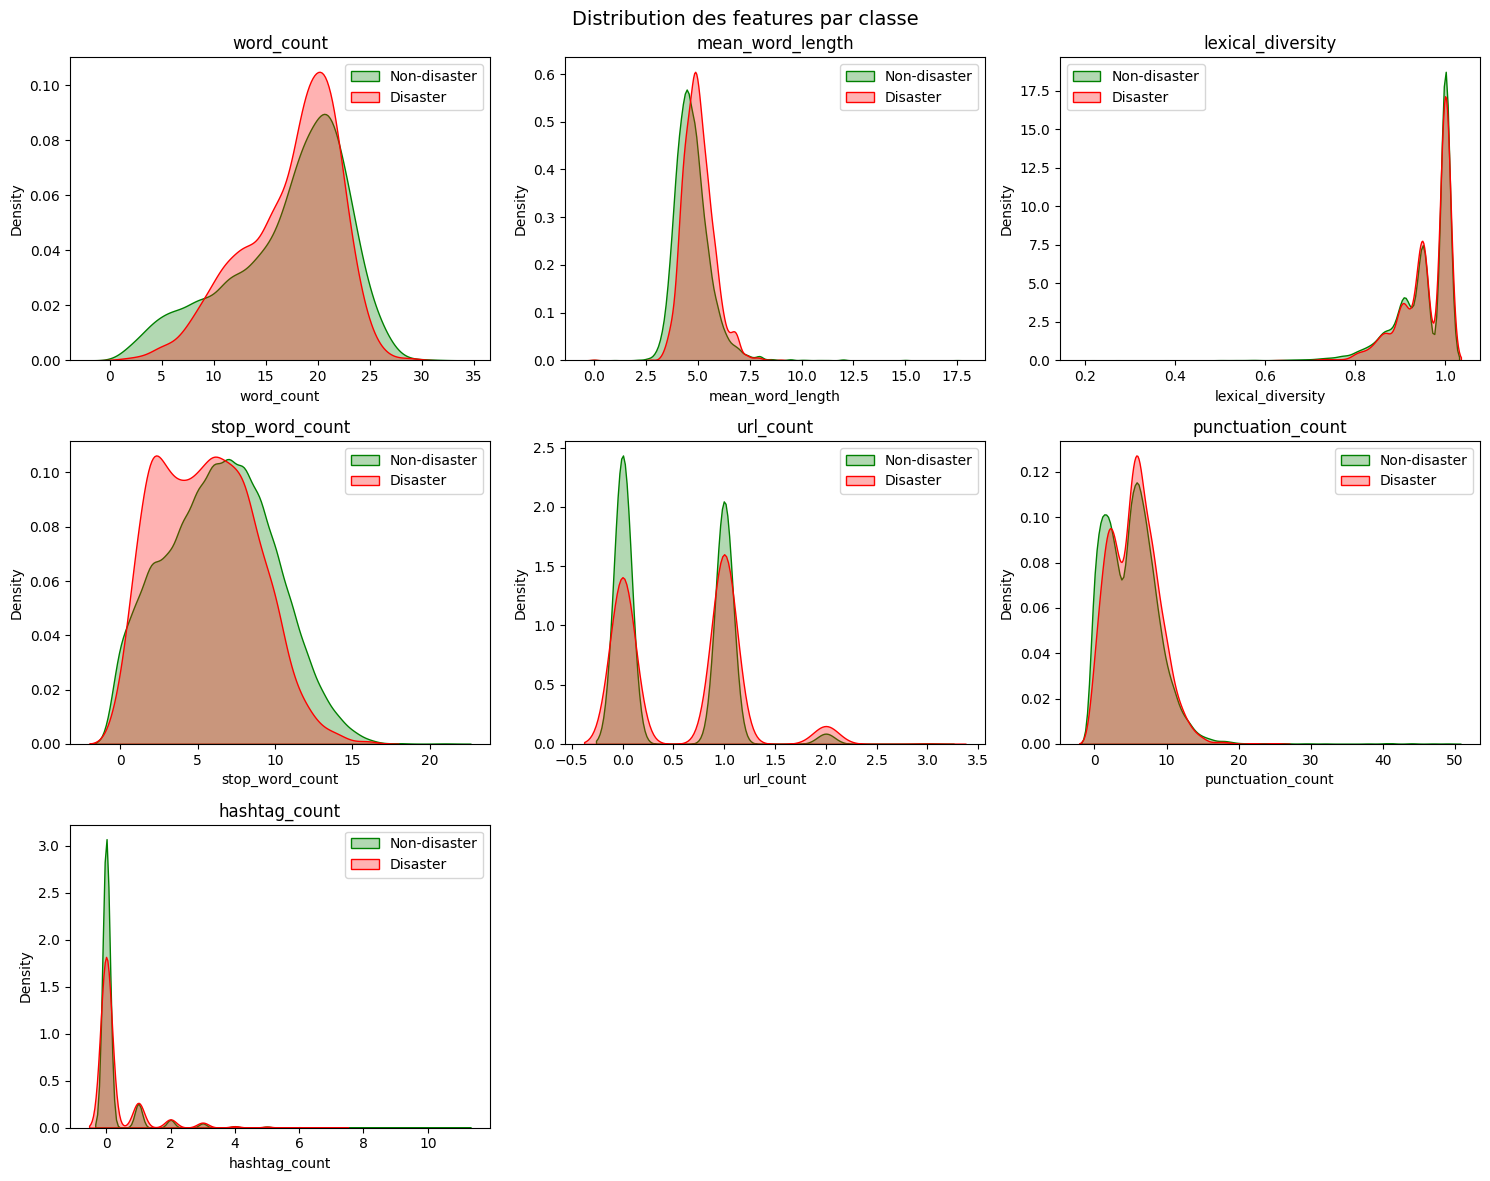

In [36]:
# Distribution de chaque feature numérique par classe (disaster vs non-disaster) (keyword est une variable categorielle)
# Les features créées sont :
# * word_count        : nombre de mots dans le texte
# * mean_word_length  : longueur moyenne des mots (en nombre de caractères)
# * lexical_diversity : ratio entre le nombre de mots uniques et le nombre total de mots
# * stop_word_count   : nombre de mots de liaison (is, the, a,...) dans le texte
# * url_count         : nombre d'URLs dans le texte
# * punctuation_count : nombre de signes de ponctuation dans le texte
# * hashtag_count     : nombre de hashtags (#) dans le texte

features = ['word_count', 'mean_word_length', 'lexical_diversity', 
            'stop_word_count', 'url_count', 'punctuation_count', 
            'hashtag_count']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(data[data['target']==0][feature], 
                ax=axes[i], color='green', label='Non-disaster', fill=True, alpha=0.3)
    sns.kdeplot(data[data['target']==1][feature], 
                ax=axes[i], color='red', label='Disaster', fill=True, alpha=0.3)
    axes[i].set_title(f'{feature}')
    axes[i].legend()

# Supprimer les subplots vides (9 cases pour 7 features)
axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.suptitle('Distribution des features par classe', fontsize=14)
plt.tight_layout()
plt.show()

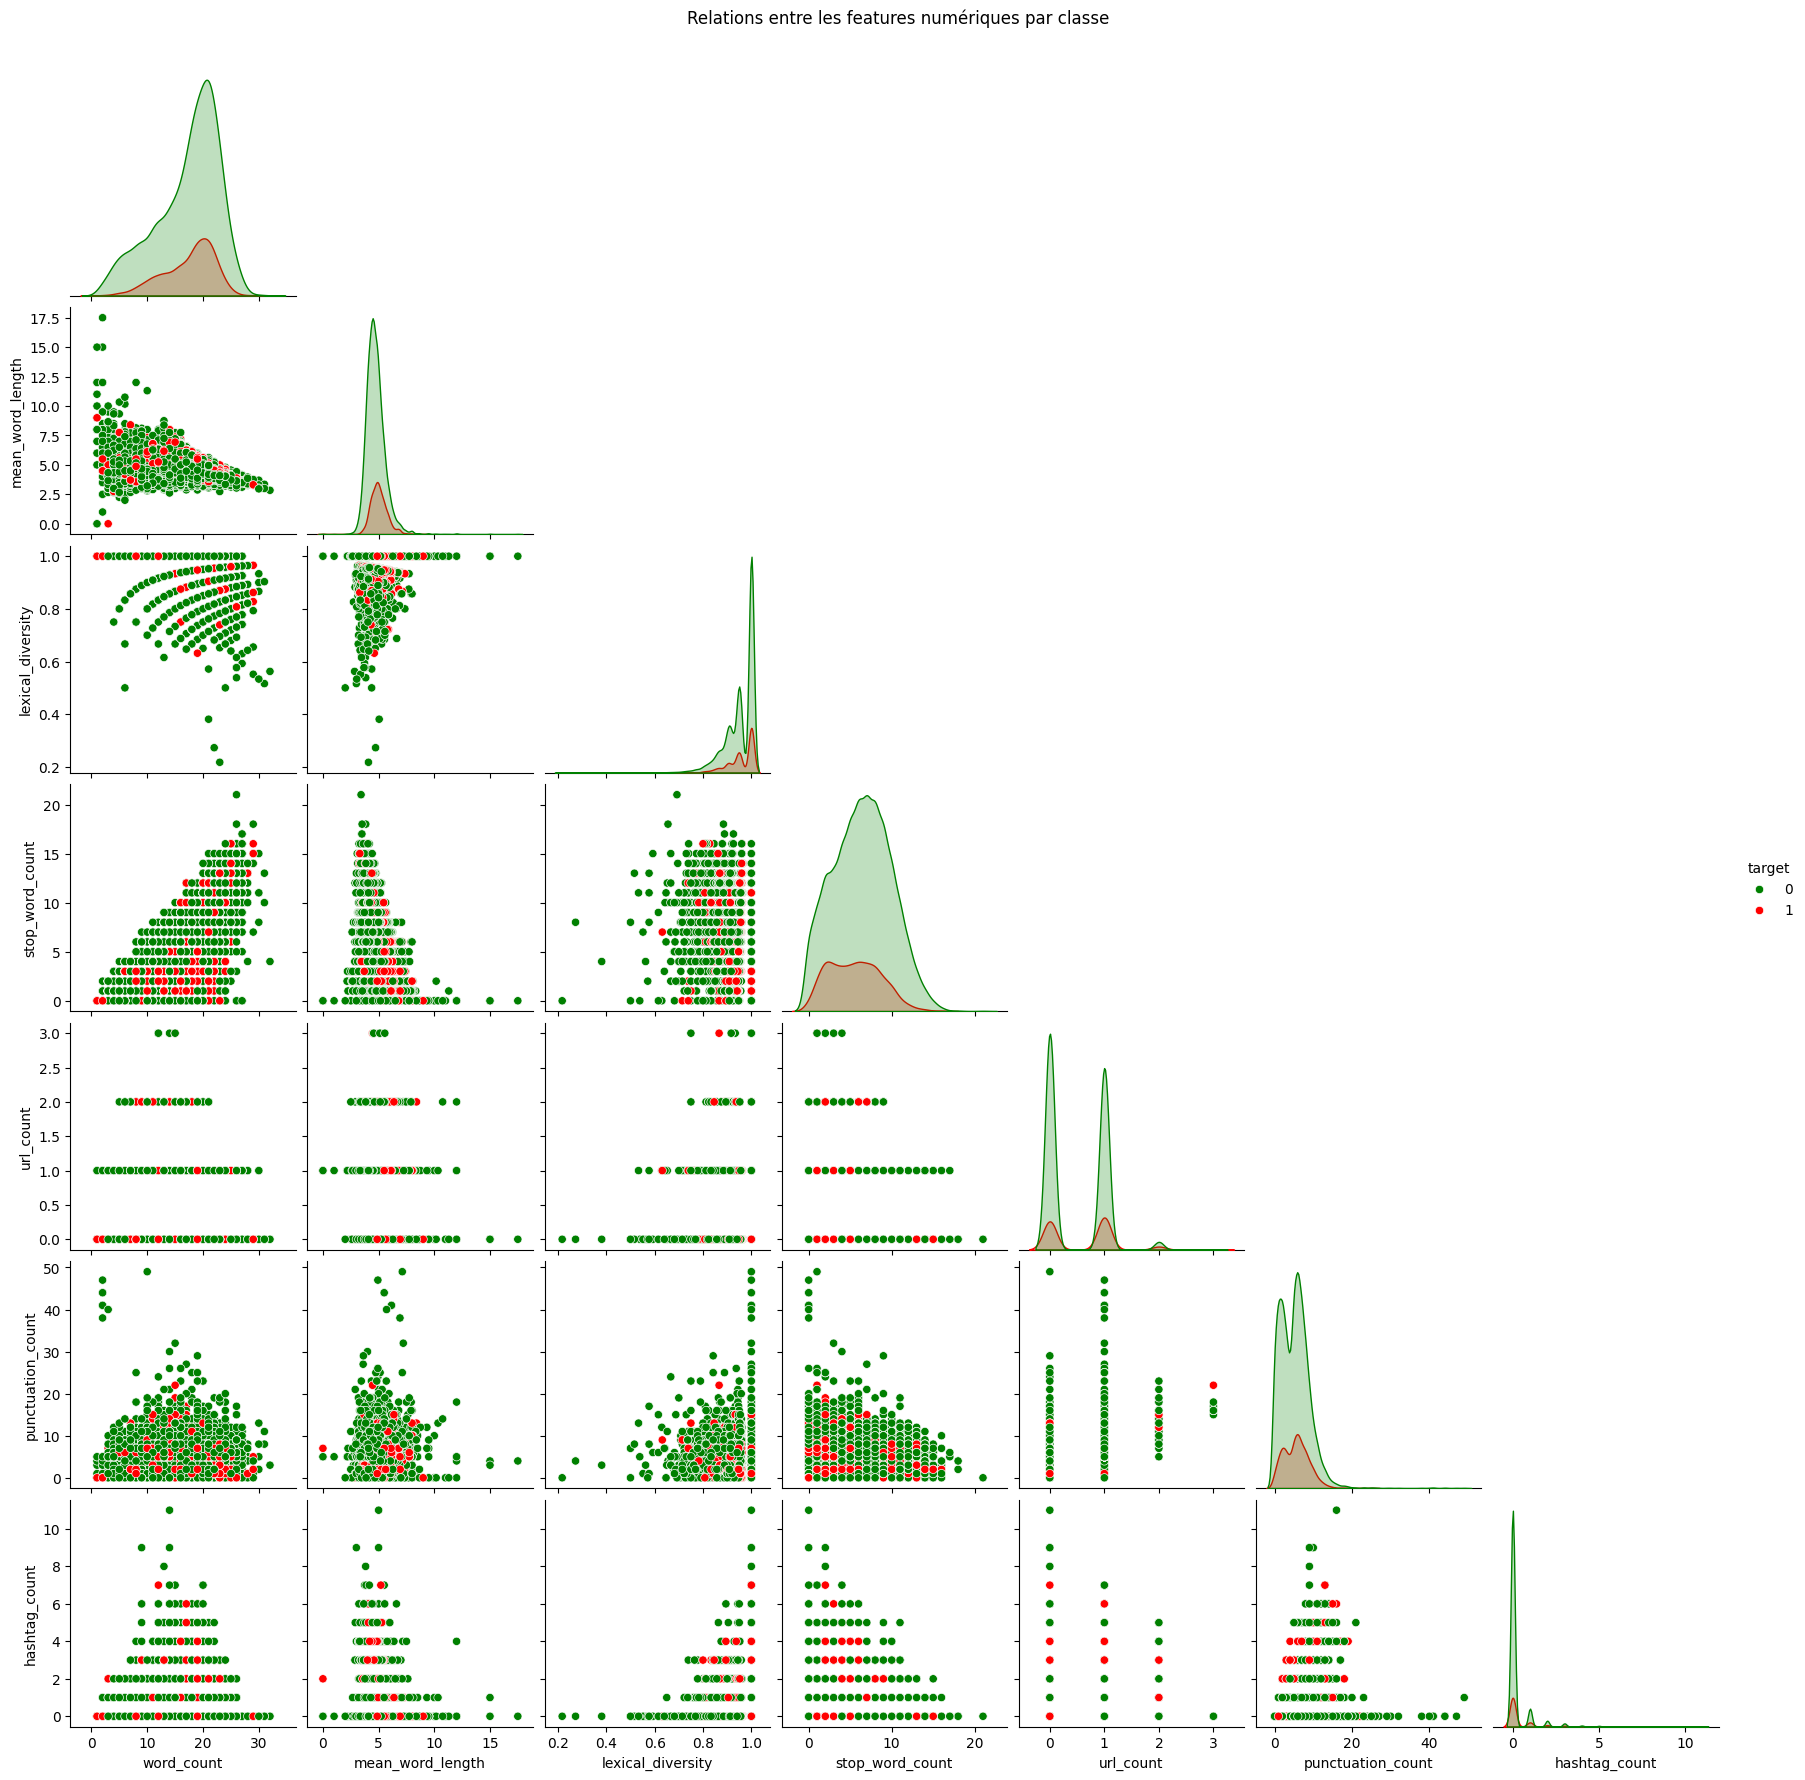

In [37]:
# Pairplot : relations entre toutes les features numériques par classe
sns.pairplot(data[['word_count', 'mean_word_length', 'lexical_diversity',
                    'stop_word_count', 'url_count', 'punctuation_count',
                    'hashtag_count', 'target']],
             hue='target',
             corner=True,
             palette={0: 'green', 1: 'red'})
plt.suptitle('Relations entre les features numériques par classe', y=1.02)
plt.show()

#vert = non-disaster, rouge = disaster

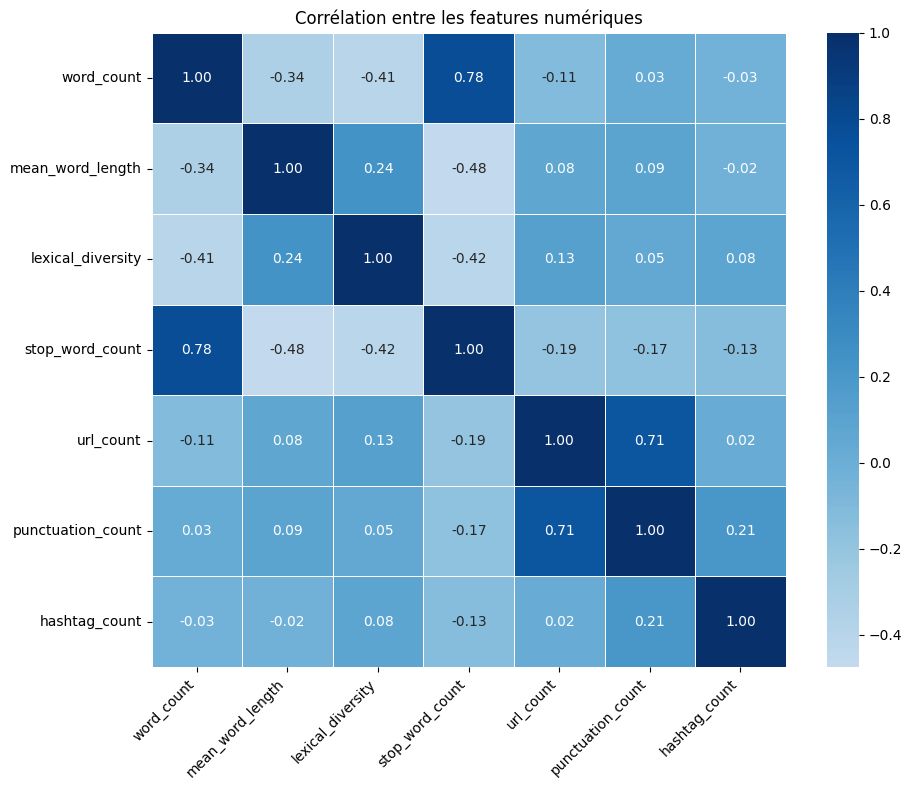

In [38]:
# Heatmap de corrélation entre les features numériques
features = ['word_count', 'mean_word_length', 'lexical_diversity', 
            'stop_word_count', 'url_count', 'punctuation_count', 
            'hashtag_count']

plt.figure(figsize=(10, 8))
sns.heatmap(data[features].corr(), 
            annot=True, fmt='.2f', cmap='Blues', 
            center=0, square=True, linewidths=0.5)
plt.title('Corrélation entre les features numériques')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La heatmap révèle deux corrélations importantes entre les features :
* word_count et stop_word_count sont fortement corrélés (0,78), ce qui est 
  attendu car les stopwords font partie des mots du tweet. Cette redondance 
  partielle est acceptable car les deux features capturent des aspects 
  légèrement différents (volume total vs proportion de mots de liaison).
* url_count et punctuation_count sont corrélés à 0,71 : les caractères 
spéciaux des URLs (://, ., /) étant comptabilisés comme ponctuation.
Les autres features (hashtag_count, lexical_diversity, mean_word_length) 
sont peu corrélées entre elles, confirmant qu'elles capturent des 
informations complémentaires et non redondantes, ce qui est favorable 
pour la modélisation.

# **3. Préparation : Nettoyage des données et normalisation**

In [39]:
# Transformation de url_count en variable binaire
data['url_count'] = (data['url_count'] > 0).astype(int)

# Répartition par classe
print('Répartition de url_count par classe :')
print(data.groupby('target')['url_count'].value_counts())
print('\nPourcentage :')
print(data.groupby('target')['url_count'].value_counts(normalize=True) * 100)

Répartition de url_count par classe :
target  url_count
0       0            4873
        1            4278
1       1            1150
        0             923
Name: count, dtype: int64

Pourcentage :
target  url_count
0       0            53.251011
        1            46.748989
1       1            55.475157
        0            44.524843
Name: proportion, dtype: float64


In [40]:
#Vérifions que les features créées sont statistiquement significatives
from sklearn.feature_selection import SelectKBest, f_classif  # sélection des meilleures features par test statistique (ANOVA F-test)

# Liste des features numériques
features_num = ['word_count', 'mean_word_length', 'lexical_diversity', 
                'stop_word_count', 'url_count', 'punctuation_count', 
                'hashtag_count']

# Test statistique de chaque feature vs target
selector = SelectKBest(f_classif, k='all')
selector.fit(data[features_num], data['target'])

# Scores et p-values
feature_scores = pd.DataFrame({
    'feature': features_num,
    'score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('score', ascending=False)
print(feature_scores)

             feature       score       p_value
1   mean_word_length  199.462905  6.626451e-45
3    stop_word_count  115.520762  8.172664e-27
4          url_count   51.762545  6.662755e-13
6      hashtag_count   43.614988  4.178270e-11
5  punctuation_count   19.506800  1.011808e-05
2  lexical_diversity   16.720110  4.362155e-05
0         word_count    4.268270  3.885335e-02


Le test statistique ANOVA F-test révèle que toutes les 7 features numeriques sont statistiquement significatives (p-value < 0,05). mean_word_length est la feature la plus discriminante avec un score de 201,64, confirmant que la longueur moyenne des mots est le meilleur indicateur structural pour distinguer les tweets disaster des non-disaster.

In [41]:
data.head()

,id,keyword,location,text,target,word_count,mean_word_length,lexical_diversity,stop_word_count,url_count,punctuation_count,hashtag_count
0,0,ablaze,NaN,"communal violence in bhainsa, telangana. ""ston...",1,19,5.631579,0.842105,7,0,4,0
1,1,ablaze,NaN,telangana: section 144 has been imposed in bha...,1,23,4.739130,0.956522,8,0,3,0
2,2,ablaze,New York City,arsonist sets cars ablaze at dealership https:...,1,7,5.666667,1.000000,1,1,5,0
3,3,ablaze,"Morgantown, WV",arsonist sets cars ablaze at dealership https:...,1,8,5.666667,1.000000,1,1,10,0
4,4,ablaze,NaN,"""lord jesus, your love brings freedom and pard...",0,23,4.318182,0.826087,9,1,8,0


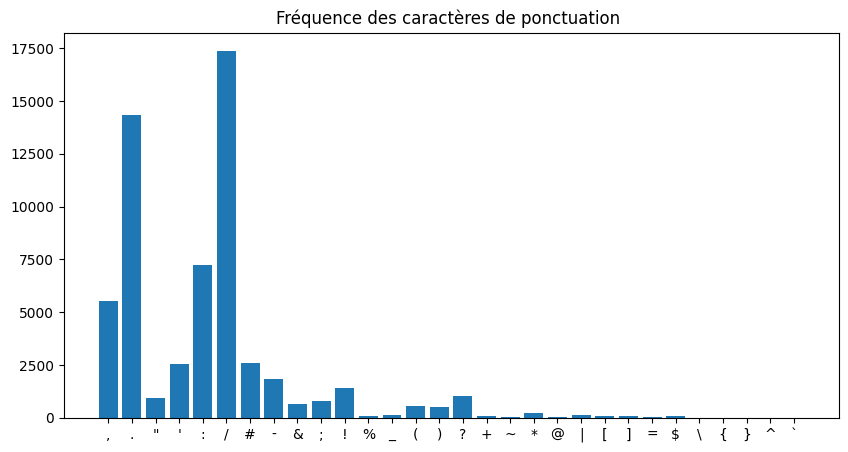

In [42]:
# Affichage de la frequence des caracteres speciaux et de ponctuation dans les tweets 
plt.figure(figsize=(10,5))

# Création de la liste de tous les mots des tweets 
corpus = []
for tweet in data['text'].str.split():
    for word in tweet:
        corpus.append(word)

# Comptage des caractères de ponctuation présents dans le corpus
dic = defaultdict(int)
special = string.punctuation
for word in corpus:
    for char in word:
        if char in special:
            dic[char] += 1

x, y = zip(*dic.items())
plt.bar(x, y)
plt.title('Fréquence des caractères de ponctuation ')
plt.show()

**La variable text doit être nettoyé de ces caractères spéciaux**

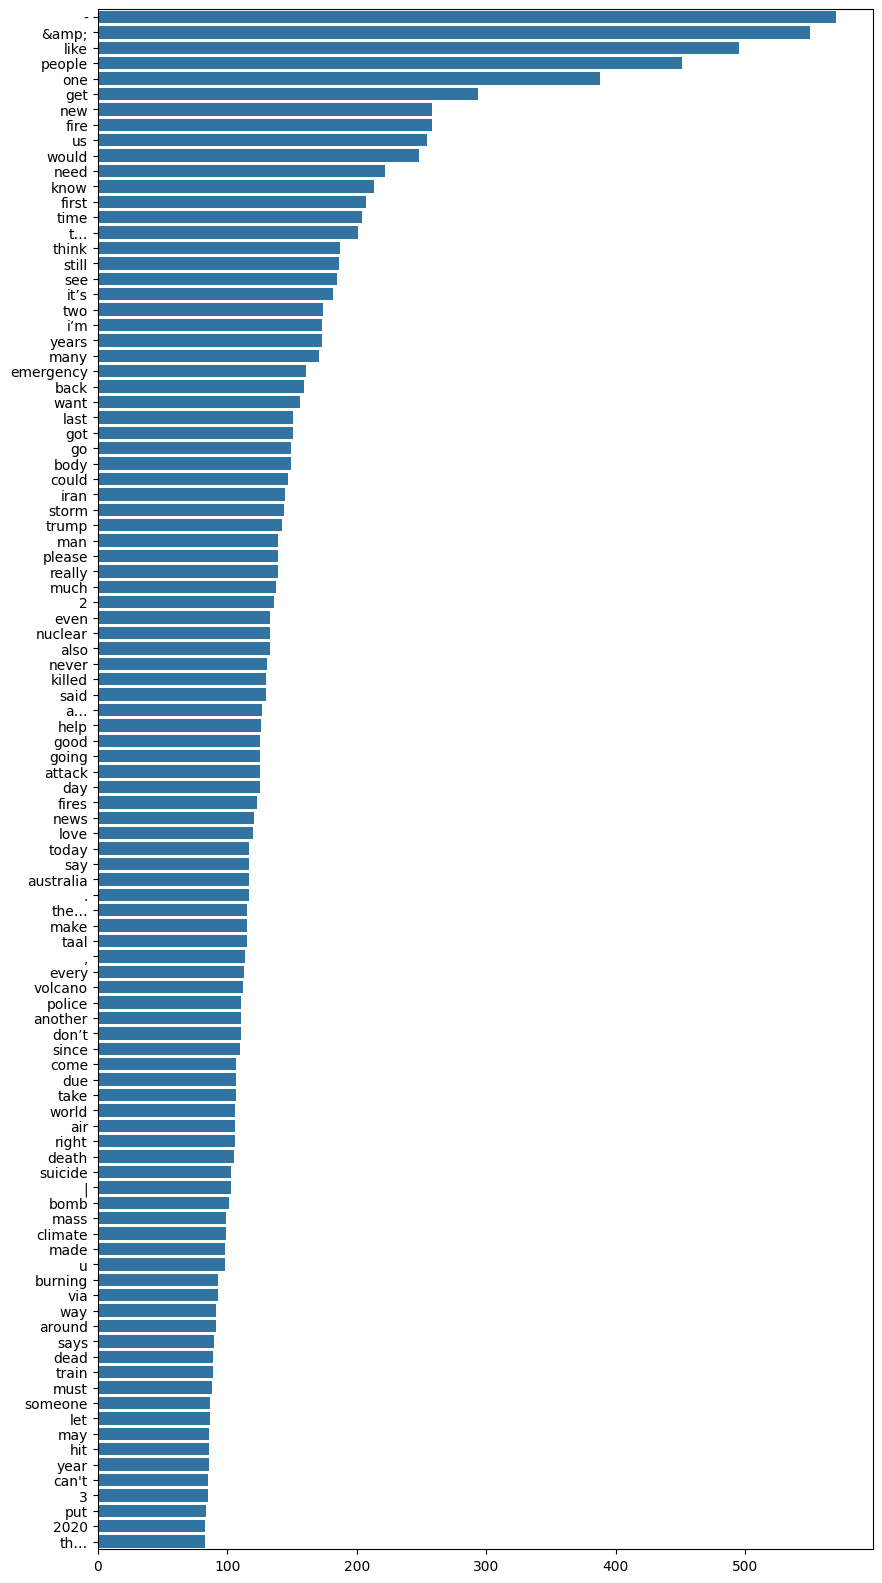

In [43]:
# Verifions quels sont les mots les plus frequents (hors stop word) dans le dataset
stop = set(stopwords.words('english'))  # ensemble des stopwords en anglais (the, is, in,...)

# Comptage des occurrences de chaque mot du corpus defini plus haut (liste de tous les mots des tweets)
counter = Counter(corpus)
most = counter.most_common()
x = []
y = []
for word, count in most:  # parcourt tous les mots
    if word not in stop:
        x.append(word)
        y.append(count)
        if len(x) == 100:  # on arrête une fois qu'on a 100 mots valides
            break

plt.figure(figsize=(10,20))  # agrandir la figure pour que les labels restent lisibles
sns.barplot(x=y, y=x)
plt.show()

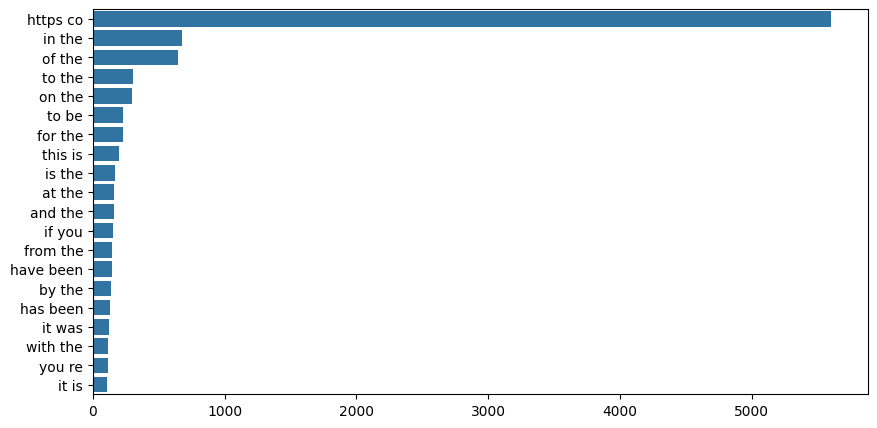

In [44]:
def get_top_tweet_bigrams(corpus, n=None):
    # Crée un vectorizer qui compte les paires de mots consécutifs ou bigrammes
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    # Somme les occurrences de chaque bigramme sur tout le corpus
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # Tri par fréquence décroissante
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Top 20 des bigrammes les plus fréquents dans tous les tweets
plt.figure(figsize=(10,5))
top_tweet_bigrams = get_top_tweet_bigrams(data['text'])[:20]
x, y = map(list, zip(*top_tweet_bigrams))
sns.barplot(x=y, y=x)
plt.show()

**Donc, il faut supprimer les liens URL et les fautes d'orthographe contenue dans la variable text**

In [45]:
# Créons la variable text_clean qui va stocker une version en minuscule du texte brut
data['text_clean'] = data['text'].str.lower()

**Regardons la prévalence des émojis dans les tweets pour décider de leur conservation ou suppression.**

In [46]:
# Détection des tweets contenant des emojis
import emoji 
mask = data['text'].apply(lambda x: any(char in emoji.EMOJI_DATA for char in x))
print(f"Nombre de tweets contenant des emojis : {mask.sum()}")
data[mask][['text', 'target']].head(20)

Nombre de tweets contenant des emojis : 928


,text,target
17,rengoku sets my heart ablaze😔❤️🔥 p.s. i missed...,0
35,📷 heartfelt appreciation to prime minister yab...,0
37,❤️❤️❤️ he gave us everything... he had a horri...,0
38,"😁yeah! his new swag is on point 100%, since th...",0
41,my back and neck are still fucked up from the ...,0
62,"👀look at this shit,😠she need her little ass wh...",0
96,nah i need calm down 💀 https://t.co/eokphshn5r,0
97,thinking about how some1 spat blood at me duri...,0
100,i don't think silivri m4.8 is an aftershock of...,0
107,how could you leave when i gave you my all 💔,0


In [47]:
# Répartition des tweets avec emojis par classe
print("Répartition des tweets avec emojis par classe :")
print(data[mask].groupby('target').size())
print("\nPourcentage par classe :")
print(data[mask].groupby('target').size() / data.groupby('target').size() * 100)

Répartition des tweets avec emojis par classe :
target
0    825
1    103
dtype: int64

Pourcentage par classe :
target
0    9.015408
1    4.968644
dtype: float64


In [48]:
from collections import Counter

# Extraction de tous les emojis par classe
def extract_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]

# Emojis par classe
emojis_disaster = []
emojis_non_disaster = []

for text in data[data['target']==1]['text']:
    emojis_disaster.extend(extract_emojis(text))
    
for text in data[data['target']==0]['text']:
    emojis_non_disaster.extend(extract_emojis(text))

# Comptage
counter_disaster = Counter(emojis_disaster)
counter_non_disaster = Counter(emojis_non_disaster)

# Emojis présents dans les deux classes
common_emojis = set(counter_disaster.keys()) & set(counter_non_disaster.keys())
print(f"Nombre d'emojis communs aux deux classes : {len(common_emojis)}")

# Total par classe
total_disaster = sum(counter_disaster.values())
total_non_disaster = sum(counter_non_disaster.values())

# Tableau comparatif
emoji_df = pd.DataFrame([{
    'emoji'           : e,
    'count_disaster'  : counter_disaster[e],
    'count_non_disaster' : counter_non_disaster[e],
    'pct_disaster'    : counter_disaster[e] / total_disaster * 100,
    'pct_non_disaster': counter_non_disaster[e] / total_non_disaster * 100
} for e in common_emojis])

emoji_df = emoji_df.sort_values('count_non_disaster', ascending=False)
print(emoji_df.head(20))

Nombre d'emojis communs aux deux classes : 56
   emoji  count_disaster  count_non_disaster  pct_disaster  pct_non_disaster
20     😂              10                 242      4.366812         13.145030
39     😭              16                 118      6.986900          6.409560
5      🤣               4                  69      1.746725          3.747963
32     🔥               8                  60      3.493450          3.259098
1      🙏              34                  58     14.847162          3.150462
55     ❤               2                  41      0.873362          2.227051
10     🥺               1                  31      0.436681          1.683867
33     ✅               2                  27      0.873362          1.466594
49     😳               8                  23      3.493450          1.249321
40     🏻               2                  22      0.873362          1.195003
37     🚨               1                  21      0.436681          1.140684
11     🤔               2      

In [49]:
# Nombre total d'emojis dans disaster (pas de tweets, mais d'occurrences d'emojis)
print(f"Nombre total d'occurrences d'emojis dans disaster : {total_disaster}")
print(f"Nombre total d'occurrences d'emojis dans non-disaster : {total_non_disaster}")

# Nombre d'emojis uniques (types différents) par classe
print(f"Nombre de types d'emojis différents dans disaster : {len(counter_disaster)}")
print(f"Nombre de types d'emojis différents dans non-disaster : {len(counter_non_disaster)}")
print(f"Communs aux deux classes : {len(common_emojis)}")

Nombre total d'occurrences d'emojis dans disaster : 229
Nombre total d'occurrences d'emojis dans non-disaster : 1841
Nombre de types d'emojis différents dans disaster : 69
Nombre de types d'emojis différents dans non-disaster : 324
Communs aux deux classes : 56


In [50]:
# Emojis présents uniquement dans les tweets disaster
only_disaster = set(counter_disaster.keys()) - set(counter_non_disaster.keys())
print(f"Nombre d'emojis uniquement dans disaster : {len(only_disaster)}")

# Tableau avec fréquences
emoji_only_disaster = pd.DataFrame([{
    'emoji'          : e,
    'count'          : counter_disaster[e],
    'pct_disaster'   : counter_disaster[e] / total_disaster * 100
} for e in only_disaster])

emoji_only_disaster = emoji_only_disaster.sort_values('count', ascending=False)
print(emoji_only_disaster)

Nombre d'emojis uniquement dans disaster : 13
   emoji  count  pct_disaster
11     🔗      6      2.620087
2      🚏      2      0.873362
3      ⬆      2      0.873362
8      ☘      2      0.873362
0      🚒      2      0.873362
12     🌩      2      0.873362
1      👶      1      0.436681
4      📞      1      0.436681
5      🚘      1      0.436681
7      🎾      1      0.436681
6      😶      1      0.436681
10     ✈      1      0.436681
9      😖      1      0.436681


Bien que 928 tweets (8,2% du total) contiennent des emojis, leur analyse révèle 
qu'ils sont majoritairement utilisés dans un sens figuré ou hyperbolique 
(ex: 🔥 pour "c'est incroyable" plutôt que pour signaler un incendie ou "	rengoku sets my heart ablaze😔❤️🔥" qui ne désigne clairement pas un incendie). 
Avec seulement 13 types d'emojis exclusifs aux tweets disaster sur 
103 tweets concernés, leur pouvoir discriminant est jugé insuffisant. 
Les emojis sont donc supprimés lors du nettoyage du texte.

In [51]:
import re      # expressions régulières pour rechercher et remplacer des motifs dans le texte
import html    # décodage des entités HTML (&amp; → &, &lt; → <,...)
import emoji   # gestion des emojis (suppression)

import nltk
nltk.data.path.append('/kaggle/input/stopwords')
from nltk.corpus import stopwords  # liste de mots courants sans valeur informative (the, a, in, is,...)
STOPWORDS_EN = set(stopwords.words('english'))


def clean(tweet):
    """
    Nettoyage cas par cas : caractères corrompus, contractions, 
    abréviations, acronymes et hashtags nommés.
    Note : le texte est déjà en minuscules avant d'entrer dans cette fonction.
    """

    # ── 1. ENTITÉS HTML ─────────────────────────────────────────────────────
    tweet = html.unescape(tweet)
    tweet = re.sub(r">", ">", tweet)
    tweet = re.sub(r"<", "<", tweet)
    tweet = re.sub(r"&", "&", tweet)

    # ── 2. CARACTÈRES D'ENCODAGE CORROMPUS ──────────────────────────────────
    tweet = re.sub(r"\x89û_", "", tweet)
    tweet = re.sub(r"\x89ûò", "", tweet)
    tweet = re.sub(r"\x89ûó", "", tweet)
    tweet = re.sub(r"\x89ûïwhen", "when", tweet)
    tweet = re.sub(r"\x89ûï", "", tweet)
    tweet = re.sub(r"china\x89ûªs", "china is", tweet)
    tweet = re.sub(r"let\x89ûªs", "let us", tweet)
    tweet = re.sub(r"\x89û÷", "", tweet)
    tweet = re.sub(r"\x89ûª", "", tweet)
    tweet = re.sub(r"\x89û\x9d", "", tweet)
    tweet = re.sub(r"å_", "", tweet)
    tweet = re.sub(r"\x89û¢", "", tweet)
    tweet = re.sub(r"\x89û¢åê", "", tweet)
    tweet = re.sub(r"fromåêwounds", "from wounds", tweet)
    tweet = re.sub(r"åê", "", tweet)
    tweet = re.sub(r"åè", "", tweet)
    tweet = re.sub(r"japì_n", "japan", tweet)
    tweet = re.sub(r"ì©", "e", tweet)
    tweet = re.sub(r"å¨", "", tweet)
    tweet = re.sub(r"suruì¤", "suruc", tweet)
    tweet = re.sub(r"åç", "", tweet)
    tweet = re.sub(r"å£3million", "3 million", tweet)
    tweet = re.sub(r"åà", "", tweet)
    tweet = re.sub(r"mì¼sica", "music", tweet)

    # ── 3. CONTRACTIONS ─────────────────────────────────────────────────────
    tweet = re.sub(r"he's", "he is", tweet)
    tweet = re.sub(r"there's", "there is", tweet)
    tweet = re.sub(r"we're", "we are", tweet)
    tweet = re.sub(r"that's", "that is", tweet)
    tweet = re.sub(r"won't", "will not", tweet)
    tweet = re.sub(r"they're", "they are", tweet)
    tweet = re.sub(r"can't", "cannot", tweet)
    tweet = re.sub(r"wasn't", "was not", tweet)
    tweet = re.sub(r"don\x89ûªt", "do not", tweet)
    tweet = re.sub(r"aren't", "are not", tweet)
    tweet = re.sub(r"isn't", "is not", tweet)
    tweet = re.sub(r"what's", "what is", tweet)
    tweet = re.sub(r"haven't", "have not", tweet)
    tweet = re.sub(r"hasn't", "has not", tweet)
    tweet = re.sub(r"it's", "it is", tweet)
    tweet = re.sub(r"you're", "you are", tweet)
    tweet = re.sub(r"i'm", "i am", tweet)
    tweet = re.sub(r"i\x89ûªm", "i am", tweet)
    tweet = re.sub(r"shouldn't", "should not", tweet)
    tweet = re.sub(r"wouldn't", "would not", tweet)
    tweet = re.sub(r"here's", "here is", tweet)
    tweet = re.sub(r"you've", "you have", tweet)
    tweet = re.sub(r"you\x89ûªve", "you have", tweet)
    tweet = re.sub(r"couldn't", "could not", tweet)
    tweet = re.sub(r"we've", "we have", tweet)
    tweet = re.sub(r"it\x89ûªs", "it is", tweet)
    tweet = re.sub(r"doesn\x89ûªt", "does not", tweet)
    tweet = re.sub(r"who's", "who is", tweet)
    tweet = re.sub(r"i\x89ûªve", "i have", tweet)
    tweet = re.sub(r"y'all", "you all", tweet)
    tweet = re.sub(r"can\x89ûªt", "cannot", tweet)
    tweet = re.sub(r"would've", "would have", tweet)
    tweet = re.sub(r"it'll", "it will", tweet)
    tweet = re.sub(r"we'll", "we will", tweet)
    tweet = re.sub(r"wouldn\x89ûªt", "would not", tweet)
    tweet = re.sub(r"he'll", "he will", tweet)
    tweet = re.sub(r"weren't", "were not", tweet)
    tweet = re.sub(r"didn't", "did not", tweet)
    tweet = re.sub(r"don't", "do not", tweet)
    tweet = re.sub(r"that\x89ûªs", "that is", tweet)
    tweet = re.sub(r"they've", "they have", tweet)
    tweet = re.sub(r"i'd", "i would", tweet)
    tweet = re.sub(r"should've", "should have", tweet)
    tweet = re.sub(r"you\x89ûªre", "you are", tweet)
    tweet = re.sub(r"where's", "where is", tweet)
    tweet = re.sub(r"don\x89ûªt", "do not", tweet)
    tweet = re.sub(r"we'd", "we would", tweet)
    tweet = re.sub(r"i'll", "i will", tweet)
    tweet = re.sub(r"you\x89ûªll", "you will", tweet)
    tweet = re.sub(r"i\x89ûªd", "i would", tweet)
    tweet = re.sub(r"let's", "let us", tweet)
    tweet = re.sub(r"i've", "i have", tweet)
    tweet = re.sub(r"doesn't", "does not", tweet)
    tweet = re.sub(r"didn't", "did not", tweet)
    tweet = re.sub(r"ain't", "am not", tweet)
    tweet = re.sub(r"you'll", "you will", tweet)
    tweet = re.sub(r"you'd", "you would", tweet)
    tweet = re.sub(r"haven't", "have not", tweet)
    tweet = re.sub(r"could've", "could have", tweet)
    tweet = re.sub(r"youve", "you have", tweet)
    tweet = re.sub(r"donå«t", "do not", tweet)
    tweet = re.sub(r"they'll", "they will", tweet)
    tweet = re.sub(r"they'd", "they would", tweet)
    tweet = re.sub(r"she's", "she is", tweet)
    tweet = re.sub(r"she'll", "she will", tweet)
    tweet = re.sub(r"she'd", "she would", tweet)

    # ── 4. CONTRACTIONS RÉSIDUELLES (non couvertes par la liste ci-dessus) ──
    tweet = re.sub(r"n't", " not", tweet)
    tweet = re.sub(r"'re", " are", tweet)
    tweet = re.sub(r"'ve", " have", tweet)
    tweet = re.sub(r"'ll", " will", tweet)
    tweet = re.sub(r"'d", " would", tweet)
    tweet = re.sub(r"'s", " is", tweet)

    # ── 5. ABRÉVIATIONS, TYPOS ET SLANG ─────────────────────────────────────
    tweet = re.sub(r"w/e", "whatever", tweet)
    tweet = re.sub(r"w/", "with", tweet)
    tweet = re.sub(r"usagov", "usa government", tweet)
    tweet = re.sub(r"recentlu", "recently", tweet)
    tweet = re.sub(r"ph0tos", "photos", tweet)
    tweet = re.sub(r"amirite", "am i right", tweet)
    tweet = re.sub(r"exp0sed", "exposed", tweet)
    tweet = re.sub(r"<3", "love", tweet)
    tweet = re.sub(r"amageddon", "armageddon", tweet)
    tweet = re.sub(r"trfc", "traffic", tweet)
    tweet = re.sub(r"16yr", "16 year", tweet)
    tweet = re.sub(r"lmao", "laughing my ass off", tweet)
    tweet = re.sub(r"traumatised", "traumatized", tweet)
    tweet = re.sub(r"s2g", "swear to god", tweet)
    tweet = re.sub(r"idkidk", "i do not know i do not know", tweet)
    tweet = re.sub(r"2k15", "2015", tweet)
    tweet = re.sub(r"win10", "windows 10", tweet)
    tweet = re.sub(r"fifa16", "fifa 2016", tweet)
    tweet = re.sub(r"daesh", "isis", tweet)
    tweet = re.sub(r"epicente\b", "epicenter", tweet)
    tweet = re.sub(r"epicenterr", "epicenter", tweet)
    tweet = re.sub(r"approachng", "approaching", tweet)
    tweet = re.sub(r"evng", "evening", tweet)
    tweet = re.sub(r"sumthng", "something", tweet)
    tweet = re.sub(r"glowng", "glowing", tweet)
    tweet = re.sub(r"kindlng", "kindling", tweet)
    tweet = re.sub(r"riggd", "rigged", tweet)
    tweet = re.sub(r"evaucation", "evacuation", tweet)
    tweet = re.sub(r"hlps", "helps", tweet)
    tweet = re.sub(r"hostagesthrosw", "hostages throw", tweet)
    tweet = re.sub(r"snctions", "sanctions", tweet)
    tweet = re.sub(r"bleased", "blessed", tweet)
    tweet = re.sub(r"kostumes", "costumes", tweet)
    tweet = re.sub(r"yeeessss", "yes", tweet)
    tweet = re.sub(r"uiseful", "useful", tweet)
    tweet = re.sub(r"kowing", "knowing", tweet)
    tweet = re.sub(r"bstrd", "bastard", tweet)
    tweet = re.sub(r"bldy", "bloody", tweet)
    tweet = re.sub(r"ithats", "that is", tweet)
    tweet = re.sub(r"sicklife", "sick life", tweet)
    tweet = re.sub(r"newnewnew", "new", tweet)
    tweet = re.sub(r"remedyyyy", "remedy", tweet)
    tweet = re.sub(r"bokoharm", "boko haram", tweet)
    tweet = re.sub(r"wfocus", "focus", tweet)
    tweet = re.sub(r"hegot", "he got", tweet)
    tweet = re.sub(r"andword", "and word", tweet)
    tweet = re.sub(r"eatshit", "eat shit", tweet)
    tweet = re.sub(r"slownewsday", "slow news day", tweet)
    tweet = re.sub(r"dirtylying", "dirty lying", tweet)

    # ── 6. HASHTAGS ET COMPTES NOMMÉS ───────────────────────────────────────
    tweet = re.sub(r"irandeal", "iran deal", tweet)
    tweet = re.sub(r"nasahurricane", "nasa hurricane", tweet)
    tweet = re.sub(r"nasasolarsystem", "nasa solar system", tweet)
    tweet = re.sub(r"typhoon-devastated", "typhoon devastated", tweet)
    tweet = re.sub(r"ebolaoutbreak", "ebola outbreak", tweet)
    tweet = re.sub(r"ebolacase", "ebola case", tweet)
    tweet = re.sub(r"blacklivesmatter", "black lives matter", tweet)
    tweet = re.sub(r"blacklivesmatter", "black lives matter", tweet)
    tweet = re.sub(r"syrianrefugees", "syrian refugees", tweet)
    tweet = re.sub(r"malaysiaairlines", "malaysia airlines", tweet)
    tweet = re.sub(r"kashmirconflict", "kashmir conflict", tweet)
    tweet = re.sub(r"freekashmir", "free kashmir", tweet)
    tweet = re.sub(r"nuclearpower", "nuclear power", tweet)
    tweet = re.sub(r"whiteterrorism", "white terrorism", tweet)
    tweet = re.sub(r"extremeweather", "extreme weather", tweet)
    tweet = re.sub(r"myanmarflood", "myanmar flood", tweet)
    tweet = re.sub(r"londonfire", "london fire", tweet)
    tweet = re.sub(r"rockyfire", "rocky fire", tweet)
    tweet = re.sub(r"wawildfire", "washington wildfire", tweet)
    tweet = re.sub(r"idfire", "idaho fire", tweet)
    tweet = re.sub(r"willowfire", "willow fire", tweet)
    tweet = re.sub(r"madrivercomplex", "mad river complex", tweet)
    tweet = re.sub(r"fingerrockfire", "finger rock fire", tweet)
    tweet = re.sub(r"tankerfire", "tanker fire", tweet)
    tweet = re.sub(r"yycstorm", "calgary storm", tweet)
    tweet = re.sub(r"yycweather", "calgary weather", tweet)
    tweet = re.sub(r"calgarysun", "calgary sun", tweet)
    tweet = re.sub(r"yychail", "calgary hail", tweet)
    tweet = re.sub(r"yyctraffic", "calgary traffic", tweet)
    tweet = re.sub(r"calgaryweather", "calgary weather", tweet)
    tweet = re.sub(r"cityofcalgary", "city of calgary", tweet)
    tweet = re.sub(r"cityofcalgary", "city of calgary", tweet)
    tweet = re.sub(r"cnnbrk", "cnn breaking news", tweet)
    tweet = re.sub(r"bbcnews", "bbc news", tweet)
    tweet = re.sub(r"bbcnewsasia", "bbc news asia", tweet)
    tweet = re.sub(r"bbclive", "bbc live", tweet)
    tweet = re.sub(r"bbcone", "bbc one", tweet)
    tweet = re.sub(r"cdcgov", "centers for disease control and prevention", tweet)
    tweet = re.sub(r"auspol", "australian politics", tweet)
    tweet = re.sub(r"gofundme", "go fund me", tweet)
    tweet = re.sub(r"plannedparenthood", "planned parenthood", tweet)
    tweet = re.sub(r"windstorm", "wind storm", tweet)
    tweet = re.sub(r"tubestrike", "tube strike", tweet)
    tweet = re.sub(r"braininjury", "brain injury", tweet)
    tweet = re.sub(r"massiveflooding", "massive flooding", tweet)
    tweet = re.sub(r"idps:", "internally displaced people :", tweet)
    tweet = re.sub(r"njturnpike", "new jersey turnpike", tweet)
    tweet = re.sub(r"thisiswhywecanthavenicethings", "this is why we cannot have nice things", tweet)
    tweet = re.sub(r"obliteration", "obliteration", tweet)
    tweet = re.sub(r"mudslide", "mudslide", tweet)
    tweet = re.sub(r"memorialday", "memorial day", tweet)
    tweet = re.sub(r"memorial_day", "memorial day", tweet)
    tweet = re.sub(r"publicsafetyfirst", "public safety first", tweet)
    tweet = re.sub(r"livesmatter", "lives matter", tweet)
    tweet = re.sub(r"gunsense", "gun sense", tweet)
    tweet = re.sub(r"twia", "texas windstorm insurance association", tweet)
    tweet = re.sub(r"txlege", "texas legislature", tweet)
    tweet = re.sub(r"windstorminsurer", "windstorm insurer", tweet)
    tweet = re.sub(r"taxiways", "taxi ways", tweet)
    tweet = re.sub(r"pray4japan", "pray for japan", tweet)
    tweet = re.sub(r"hope4japan", "hope for japan", tweet)
    tweet = re.sub(r"protectdenaliwolves", "protect denali wolves", tweet)
    tweet = re.sub(r"nuclearrcsa", "nuclear risk control self assessment", tweet)
    tweet = re.sub(r"whiteterrorism", "white terrorism", tweet)
    tweet = re.sub(r"truthfrequencyradio", "truth frequency radio", tweet)
    tweet = re.sub(r"erasureisnotequality", "erasure is not equality", tweet)
    tweet = re.sub(r"noagenda", "no agenda", tweet)
    tweet = re.sub(r"whitegenocide", "white genocide", tweet)
    tweet = re.sub(r"changetheworld", "change the world", tweet)
    tweet = re.sub(r"withweapons", "with weapons", tweet)
    tweet = re.sub(r"advancedwarfare", "advanced warfare", tweet)
    tweet = re.sub(r"letsFootball", "let us football", tweet)
    tweet = re.sub(r"wearenotgrubervoters", "we are not gruber voters", tweet)
    tweet = re.sub(r"alllivesmatter", "all lives matter", tweet)
    tweet = re.sub(r"beclearoncancer", "be clear on cancer", tweet)
    tweet = re.sub(r"standwithpp", "stand with planned parenthood", tweet)
    tweet = re.sub(r"nomore handouts", "no more handouts", tweet)
    tweet = re.sub(r"nomoreh andouts", "no more handouts", tweet)
    tweet = re.sub(r"nonukes", "no nukes", tweet)
    tweet = re.sub(r"nosurrender", "no surrender", tweet)
    tweet = re.sub(r"endconflict", "end conflict", tweet)
    tweet = re.sub(r"endoccupation", "end occupation", tweet)
    tweet = re.sub(r"youcantsitwithus", "you cannot sit with us", tweet)
    tweet = re.sub(r"weallheartonedirection", "we all heart one direction", tweet)
    tweet = re.sub(r"icouldsitinthismomentforever", "i could sit in this moment forever", tweet)
    tweet = re.sub(r"thatswhatfriendsarefor", "that is what friends are for", tweet)
    tweet = re.sub(r"thisiswhywecanthavenicethings", "this is why we cannot have nice things", tweet)
    tweet = re.sub(r"iwouldntgetelectedbecause", "i would not get elected because", tweet)
    tweet = re.sub(r"debatequestionswewanttohear", "debate questions we want to hear", tweet)
    tweet = re.sub(r"getitbeforeitsgone", "get it before it is gone", tweet)
    tweet = re.sub(r"freshoutofthebox", "fresh out of the box", tweet)
    tweet = re.sub(r"stillnotoverit", "still not over it", tweet)
    tweet = re.sub(r"feelingmanly", "feeling manly", tweet)
    tweet = re.sub(r"myhometown", "my hometown", tweet)
    tweet = re.sub(r"sebastianstanisaliveandwell", "sebastian stan is alive and well", tweet)
    tweet = re.sub(r"whatstheimportantvideo", "what is the important video", tweet)
    tweet = re.sub(r"sothathappened", "so that happened", tweet)
    tweet = re.sub(r"amwriting", "am writing", tweet)
    tweet = re.sub(r"listenlive", "listen live", tweet)
    tweet = re.sub(r"slownewsday", "slow news day", tweet)
    tweet = re.sub(r"datingtips", "dating tips", tweet)
    tweet = re.sub(r"residualincome", "residual income", tweet)
    tweet = re.sub(r"facilitiesmanagement", "facilities management", tweet)
    tweet = re.sub(r"facilitydude", "facility dude", tweet)
    tweet = re.sub(r"fieldworksmells", "field work smells", tweet)
    tweet = re.sub(r"offdishduty", "off dish duty", tweet)
    tweet = re.sub(r"showgirldayoff", "show girl day off", tweet)
    tweet = re.sub(r"concertphotography", "concert photography", tweet)
    tweet = re.sub(r"writerslife", "writers life", tweet)
    tweet = re.sub(r"newauthors", "new authors", tweet)
    tweet = re.sub(r"bedhair", "bed hair", tweet)
    tweet = re.sub(r"pctool", "pc tool", tweet)
    tweet = re.sub(r"ineedcake", "i need cake", tweet)
    tweet = re.sub(r"blackforestgateau", "black forest gateau", tweet)
    tweet = re.sub(r"incubusband", "incubus band", tweet)
    tweet = re.sub(r"irongiant", "iron giant", tweet)
    tweet = re.sub(r"redwedding", "red wedding", tweet)
    tweet = re.sub(r"savebees", "save bees", tweet)
    tweet = re.sub(r"hempoil", "hemp oil", tweet)
    tweet = re.sub(r"marijuananews", "marijuana news", tweet)
    tweet = re.sub(r"gunsense", "gun sense", tweet)
    tweet = re.sub(r"autoaccidents", "auto accidents", tweet)
    tweet = re.sub(r"birdgang", "bird gang", tweet)
    tweet = re.sub(r"buildingmuseum", "building museum", tweet)
    tweet = re.sub(r"liveleakfun", "live leak fun", tweet)
    tweet = re.sub(r"crimeairnetwork", "crime air network", tweet)
    tweet = re.sub(r"netbots", "net bots", tweet)
    tweet = re.sub(r"byebyeroad", "bye bye road", tweet)
    tweet = re.sub(r"instaxbooty", "instagram booty", tweet)
    tweet = re.sub(r"fewmoretweets", "few more tweets", tweet)
    tweet = re.sub(r"cbplawyers", "cbp lawyers", tweet)
    tweet = re.sub(r"prosyndicate", "pro syndicate", tweet)
    tweet = re.sub(r"crunchysensible", "crunchy sensible", tweet)
    tweet = re.sub(r"lavenderpoetrycafe", "lavender poetry cafe", tweet)
    tweet = re.sub(r"rhodeisland", "rhode island", tweet)
    tweet = re.sub(r"easternoregon", "eastern oregon", tweet)
    tweet = re.sub(r"rapidcity", "rapid city", tweet)
    tweet = re.sub(r"jamaicaplain", "jamaica plain", tweet)
    tweet = re.sub(r"japton", "arkansas", tweet)
    tweet = re.sub(r"missionhills", "mission hills", tweet)
    tweet = re.sub(r"southdowns", "south downs", tweet)
    tweet = re.sub(r"fortitudevalley", "fortitude valley", tweet)
    tweet = re.sub(r"northiowa", "north iowa", tweet)
    tweet = re.sub(r"nankana", "nankana", tweet)
    tweet = re.sub(r"sahib", "sahib", tweet)
    tweet = re.sub(r"pakpattan", "pakpattan", tweet)

    # ── 7. ACRONYMES ────────────────────────────────────────────────────────
    tweet = re.sub(r"mh370", "malaysia airlines flight 370", tweet)
    tweet = re.sub(r"okwx", "oklahoma city weather", tweet)
    tweet = re.sub(r"arwx", "arkansas weather", tweet)
    tweet = re.sub(r"gawx", "georgia weather", tweet)
    tweet = re.sub(r"scwx", "south carolina weather", tweet)
    tweet = re.sub(r"cawx", "california weather", tweet)
    tweet = re.sub(r"tnwx", "tennessee weather", tweet)
    tweet = re.sub(r"azwx", "arizona weather", tweet)
    tweet = re.sub(r"alwx", "alabama weather", tweet)
    tweet = re.sub(r"wordpressdotcom", "wordpress", tweet)
    tweet = re.sub(r"usnwsgov", "united states national weather service", tweet)
    tweet = re.sub(r"suruc", "sanliurfa", tweet)
    tweet = re.sub(r"bestnaijamade", "best naija made", tweet)
    tweet = re.sub(r"soudelor", "soudelor", tweet)

    # ── 8. NORMALISATION FINALE ──────────────────────────────────────────────
    tweet = re.sub(r'\s+', ' ', tweet).strip()
    return tweet


def basic_clean(text):
    """
    Nettoyage générique : suppression emojis, URLs, mentions, 
    hashtags (conservation du mot), ponctuation, espaces multiples.
    Note : les chiffres sont conservés (décision méthodologique).
    Note : les emojis sont supprimés (usage majoritairement figuré,
           pouvoir discriminant insuffisant dans ce dataset).
    """
    text = str(text)

    # Suppression des emojis
    # (8.2% des tweets, majoritairement au sens figuré, peu discriminants)
    text = emoji.replace_emoji(text, replace=' ')

    # Suppression des URLs (http://, https://, www., t.co/...)
    text = re.sub(r'https?://t\.co/[a-z0-9]+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)

    # Suppression des mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Suppression du # (conservation du mot qui suit)
    text = re.sub(r'#(\w+)', r'\1', text)

    # Suppression de la ponctuation (conservation des chiffres et lettres)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def tokenize_no_stop(text):
    """Tokenisation sans stopwords et sans tokens trop courts (< 3 caractères)."""
    tokens = basic_clean(text).split()
    return [t for t in tokens if t not in STOPWORDS_EN and len(t) > 2]


def full_clean(tweet):
    """
    Pipeline complet de nettoyage :
    1. clean()      : corrections cas par cas (contractions, acronymes, encodage,...)
    2. basic_clean(): nettoyage générique (emojis, URLs, mentions, hashtags, ponctuation)
    """
    tweet = clean(tweet)
    tweet = basic_clean(tweet)
    return tweet


def clean_keyword(keyword):
    """Nettoyage du keyword : suppression %20, minuscules, ponctuation."""
    if pd.isna(keyword):
        return 'unknown'
    keyword = str(keyword).replace('%20', ' ').lower()
    keyword = re.sub(r'[^a-z0-9\s]', '', keyword)
    keyword = re.sub(r'\s+', ' ', keyword).strip()
    return keyword


# ── APPLICATION SUR LE DATASET ───────────────────────────────────────────────
# text_clean est déjà en minuscules — full_clean s'applique directement
data['text_clean'] = data['text_clean'].apply(full_clean)

# Nettoyage du keyword
data['keyword_clean'] = data['keyword'].apply(clean_keyword)

print('✅ Nettoyage appliqué avec succès')

# text_clean : texte nettoyé AVEC stopwords (pour vectorisation TF-IDF)
data['text_clean'] = data['text_clean'].apply(full_clean)

# text_tokens : texte nettoyé SANS stopwords (pour visualisations EDA)
data['text_tokens'] = data['text_clean'].apply(
    lambda x: ' '.join(tokenize_no_stop(x))
)

# Vérification
data[['text', 'text_clean', 'text_tokens']].head(5)

✅ Nettoyage appliqué avec succès


,text,text_clean,text_tokens
0,"communal violence in bhainsa, telangana. ""ston...",communal violence in bhainsa telangana stones ...,communal violence bhainsa telangana stones pel...
1,telangana: section 144 has been imposed in bha...,telangana section 144 has been imposed in bhai...,telangana section 144 imposed bhainsa january ...
2,arsonist sets cars ablaze at dealership https:...,arsonist sets cars ablaze at dealership,arsonist sets cars ablaze dealership
3,arsonist sets cars ablaze at dealership https:...,arsonist sets cars ablaze at dealership,arsonist sets cars ablaze dealership
4,"""lord jesus, your love brings freedom and pard...",lord jesus your love brings freedom and pardon...,lord jesus love brings freedom pardon fill hol...


**Nous allons passer à la lemmatisation.**
La lemmatisation est une technique de normalisation du texte qui consiste à 
réduire chaque mot à sa forme canonique (appelée lemme), en tenant compte 
de sa nature grammaticale (nom, verbe, adjectif, adverbe).

Contrairement au stemming qui coupe brutalement la fin des mots, la 
lemmatisation produit des formes réelles et correctes :

* "fires", "fired", "firing" → "fire"
* "buildings", "built"       → "building", "build"
* "casualties"               → "casualty"
* "running"    (verbe)       → "run"
* "better"     (adjectif)    → "good"

**Pourquoi lemmatiser dans ce projet ?**

Le TF-IDF traite chaque forme d'un mot comme un token distinct ; sans 
lemmatisation, "fire" et "fires" seraient deux features différentes dans 
la matrice TF-IDF, alors qu'ils portent la même information. La lemmatisation 
permet donc de :

* Réduire la dimensionnalité du vocabulaire TF-IDF
* Regrouper les variantes d'un même mot sous une seule feature
* Améliorer la généralisation du modèle sur de nouveaux tweets

In [52]:
import spacy  # traitement du langage naturel : lemmatisation, POS tagging, analyse syntaxique

# Chargement du modèle anglais de spaCy (pré-installé sur Kaggle)
nlp = spacy.load('en_core_web_sm')

def lemmatize_text(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc])

# Application sur text_clean
data['text_lemma'] = data['text_clean'].apply(lemmatize_text)

# Vérification : exemples avant/après lemmatisation
print("Exemples avant/après lemmatisation :")
data[['text_clean', 'text_lemma']].tail(30)

Exemples avant/après lemmatisation :


,text_clean,text_lemma
11194,my twat of an art teacher what grades do u nee...,my twat of an art teacher what grade do u need...
11195,my first listen was also in the whip i damn ne...,my first listen be also in the whip I damn nea...
11196,he s not a journalist and doesn t pretend to b...,he s not a journalist and doesn t pretend to b...
11197,by all means give up sugar and carbs your body...,by all mean give up sugar and carb your body d...
11198,chanyeol 2k19 gaming destroys me messed my min...,chanyeol 2k19 gaming destroy I mess my mind wr...
11199,he will be wrecked if that happens,he will be wreck if that happen
11200,he is the oxygen that pumps blood to my living...,he be the oxygen that pump blood to my live he...
11201,when you re watching clemson get wrecked and s...,when you re watch clemson get wreck and see th...
11202,why would operators put new buses on school co...,why would operator put new bus on school contr...
11203,democratic propaganda wrecked libya obama just...,democratic propaganda wreck libya obama just h...


# 4. Split train/test

In [53]:
from sklearn.model_selection import train_test_split  # division du dataset en ensembles d'entraînement et de test

# ── SPLIT TRAIN/TEST ─────────────────────────────────────────────────────────
train, test = train_test_split(
    data,
    test_size=0.2,           # 80% train, 20% test
    random_state=42,         # reproductibilité
    stratify=data['target']  # conservation des proportions disaster/non-disaster (81.4% / 18.6%)
)

train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

# Vérification des tailles
print(f"Train : {train.shape[0]} tweets ({train.shape[0]/len(data)*100:.1f}%)")
print(f"Test  : {test.shape[0]} tweets ({test.shape[0]/len(data)*100:.1f}%)")
print(f"Test  : {test.shape} ")
print(f"Train  : {train.shape} ")
# Vérification de la stratification
print(f"\nDistribution target - Train :")
print(train['target'].value_counts(normalize=True) * 100)
print(f"\nDistribution target - Test :")
print(test['target'].value_counts(normalize=True) * 100)

train.head(10)

Train : 8979 tweets (80.0%)
Test  : 2245 tweets (20.0%)
Test  : (2245, 16) 
Train  : (8979, 16) 

Distribution target - Train :
target
0    81.534692
1    18.465308
Name: proportion, dtype: float64

Distribution target - Test :
target
0    81.514477
1    18.485523
Name: proportion, dtype: float64


,id,keyword,location,text,target,word_count,mean_word_length,lexical_diversity,stop_word_count,url_count,punctuation_count,hashtag_count,text_clean,keyword_clean,text_tokens,text_lemma
0,7448,meltdown,"Idaho, USA","god i love when liberals preach the hate, and ...",0,20,4.315789,0.900000,7,1,7,0,god i love when liberals preach the hate and b...,meltdown,god love liberals preach hate blame supporters...,god I love when liberal preach the hate and bl...
1,2116,catastrophe,NaN,"water being trucked in , watching 7, 30 this i...",0,17,4.750000,1.000000,5,1,7,0,water being trucked in watching 7 30 this is l...,catastrophe,water trucked watching looking like biggest on...,water be truck in watch 7 30 this be look like...
2,609,attacked,NaN,india attacked by islamic terrorists (again) -...,1,19,5.684211,0.947368,2,0,7,0,india attacked by islamic terrorists again lef...,attacked,india attacked islamic terrorists leftist medi...,india attack by islamic terrorist again leftis...
3,6218,hazard,Brisbane,see how close you get to hazard with the ugprades,0,10,4.000000,1.000000,5,0,0,0,see how close you get to hazard with the ugprades,hazard,see close get hazard ugprades,see how close you get to hazard with the ugprade
4,5303,famine,The land of Sanatan Dharma,the britain had tendered apologies to other na...,0,20,5.200000,1.000000,8,0,0,0,the britain had tendered apologies to other na...,famine,britain tendered apologies nations including k...,the britain have tender apology to other natio...
5,8971,screaming,loonatheworld,i was at the dentist and a woman is screaming ...,1,19,3.736842,1.000000,10,0,0,0,i was at the dentist and a woman is screaming ...,screaming,dentist woman screaming outside looks crazy sc...,I be at the dentist and a woman be scream outs...
6,7250,mass%20murder,NaN,"the dems, were for iran last week, when iran a...",0,20,4.263158,0.950000,8,1,9,0,the dems were for iran last week when iran att...,mass murder,dems iran last week iran attacked embassy iraq...,the dem be for iran last week when iran attack...
7,7363,massacre,NaN,"absolutely! and all this, after the uss libert...",1,24,4.333333,0.875000,9,0,5,0,absolutely and all this after the uss liberty ...,massacre,absolutely uss liberty massacre june 1967 hand...,absolutely and all this after the uss liberty ...
8,314,annihilation,NaN,you need to survive to practice faith. why do ...,1,13,5.000000,0.846154,6,1,7,0,you need to survive to practice faith why do y...,annihilation,need survive practice faith think hindu genocide,you need to survive to practice faith why do y...
9,360,apocalypse,NaN,👍 on : what to wear in a zombie apocalypse (zo...,0,14,4.153846,1.000000,5,1,8,0,on what to wear in a zombie apocalypse zombie ...,apocalypse,wear zombie apocalypse zombie survival guide,on what to wear in a zombie apocalypse zombie ...


Voici un récapitulatif de toutes les colonnes disponibles dans le Dataframe :

**Colonnes originales**
- `id` — identifiant du tweet
- `keyword` — mot-clé original
- `location` — localisation (non utilisée)
- `text` — texte original brut
- `target` — variable cible (0/1)

**Colonnes de texte nettoyé**
- `text_clean` — texte nettoyé complet (minuscules, sans URLs, mentions, ponctuation,...)
- `text_tokens` — texte nettoyé sans stopwords (pour visualisations EDA)
- `text_lemma` — texte lemmatisé via spaCy (**utilisé pour TF-IDF**)
- `keyword_clean` — keyword nettoyé (sans %20, minuscules,...)

**Features numériques créées**
- `word_count`
- `mean_word_length`
- `lexical_diversity`
- `stop_word_count`
- `has_url`
- `punctuation_count`
- `hashtag_count`

**Pour la modélisation, on utilisera :**
- `text_lemma` → vectorisation TF-IDF
- `features_num` → features numériques complémentaires
- `target` → variable cible

**`text_tokens`, `text_clean`, `keyword_clean`** → pas utilisés dans le modèle, gardés pour référence/analyse.

=== Exemples avant/après nettoyage ===


,text,text_clean,text_lemma,target
6444,it just shows that there is more than 1/3 of t...,it just shows that there is more than 1 3 of t...,it just show that there be more than 1 3 of th...,0
93,"“according to the assembly, they have informed...",according to the assembly they have informed t...,accord to the assembly they have inform the se...,0
8448,"***a thread on pulwama attack, lapses in secur...",a thread on pulwama attack lapses in security ...,a thread on pulwama attack lapse in security u...,0
7660,venturebeat: facebook’s displacement maps trac...,venturebeat facebook s displacement maps track...,venturebeat facebook s displacement map track ...,0
994,«at the point where its shock has been the mos...,at the point where its shock has been the most...,at the point where its shock have be the most ...,0



Original : This is so sad 😭 but also amazing! ✨ ambulance 🚑 https://t.co/xyz123 #disaster
Nettoyé  : his is so sad but also amazing ambulance disaster

Keywords uniques (train) : 219
Keywords uniques (test)  : 219


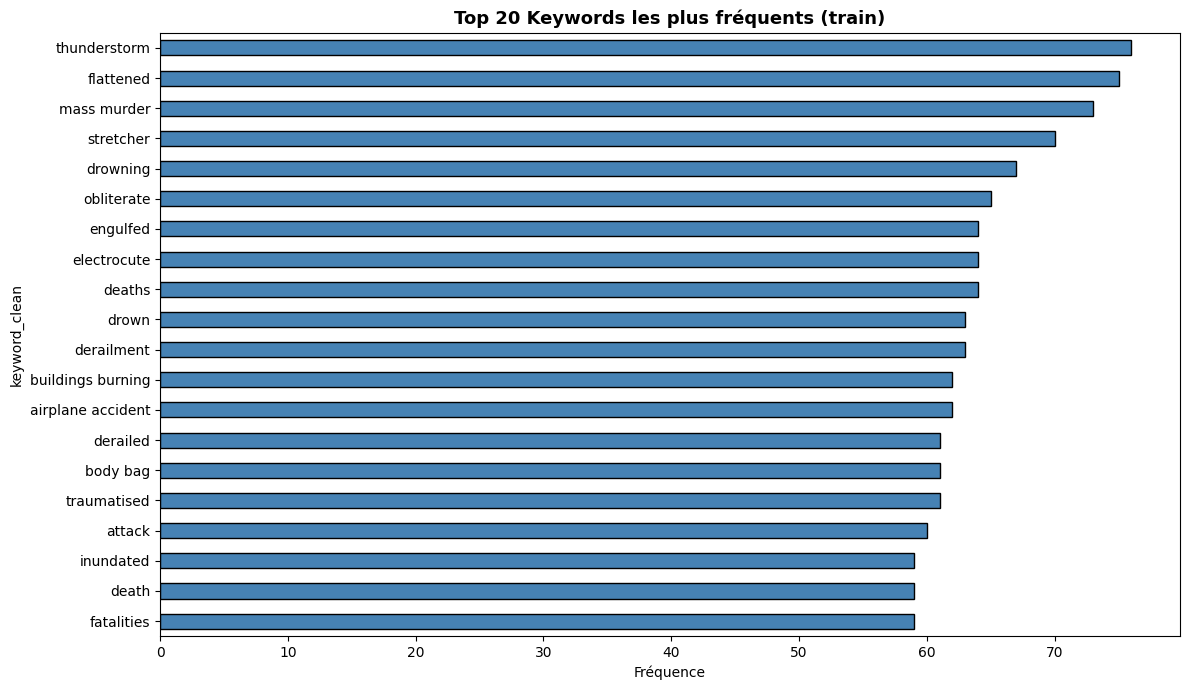

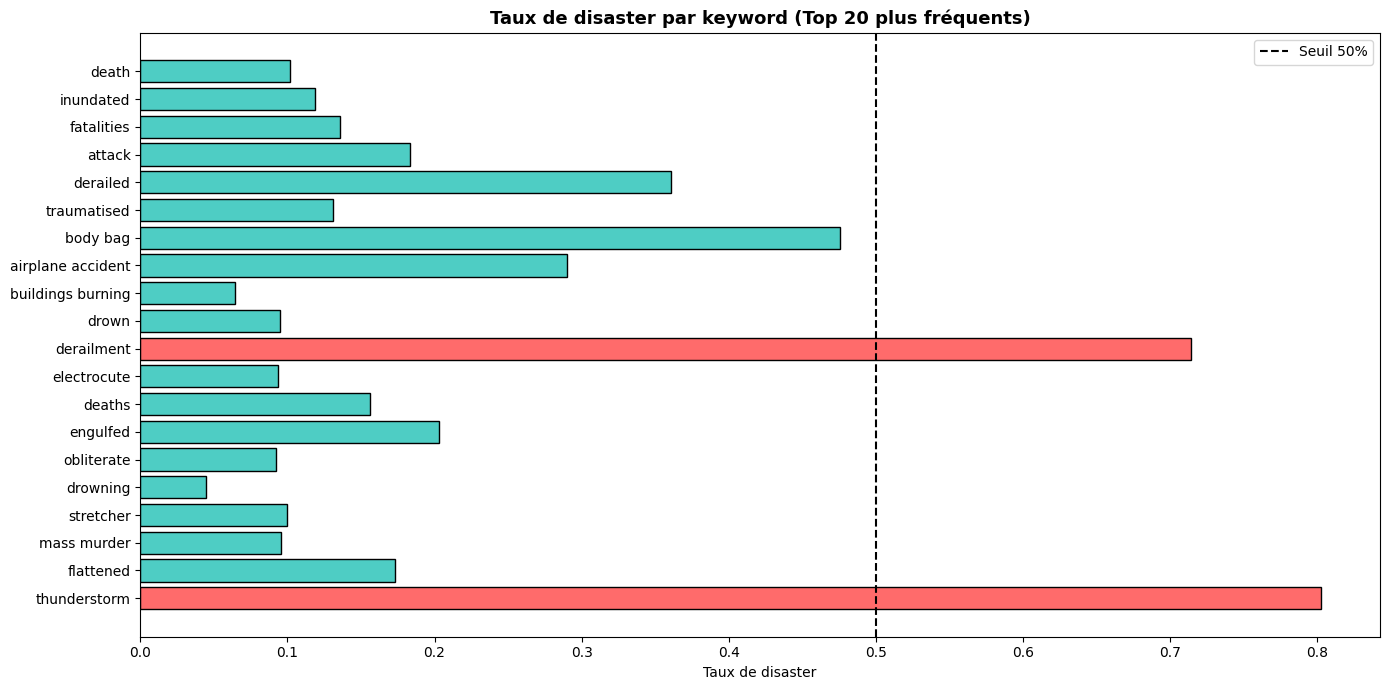


Tokens perdus après nettoyage (moyenne par classe) :
        word_count  clean_word_count  tokens_lost
target                                           
0            17.14              16.9         0.24
1            17.49              17.1         0.39


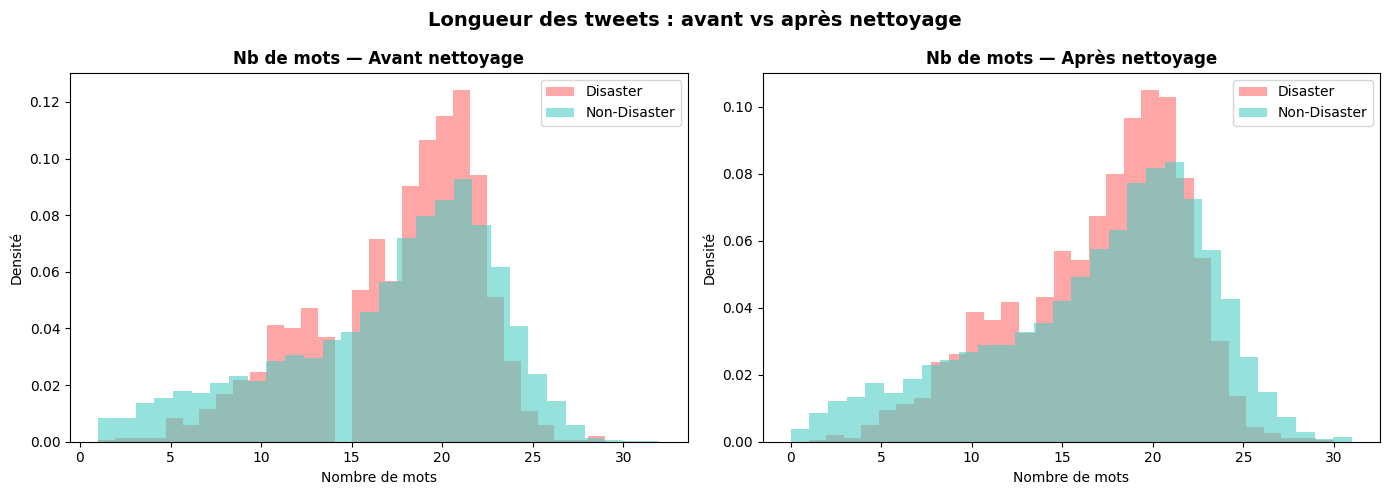

In [54]:
# ── VÉRIFICATION DU NETTOYAGE ────────────────────────────────────────────────

# 1. Exemples de tweets avant/après nettoyage
print('=== Exemples avant/après nettoyage ===')
display(train[['text', 'text_clean', 'text_lemma', 'target']].sample(5, random_state=42))

# 2. Test sur un exemple avec emoji et URL
sample = "This is so sad 😭 but also amazing! ✨ ambulance 🚑 https://t.co/xyz123 #disaster"
print(f'\nOriginal : {sample}')
print(f'Nettoyé  : {full_clean(sample)}')

# 3. Keywords uniques dans train et test
print(f"\nKeywords uniques (train) : {train['keyword_clean'].nunique()}")
print(f"Keywords uniques (test)  : {test['keyword_clean'].nunique()}")

# 4. Top 20 keywords les plus fréquents (train)
top_kw = train['keyword_clean'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 7))
top_kw.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 20 Keywords les plus fréquents (train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

# 5. Taux de disaster par keyword (top 20)
kw_stats = (
    train.groupby('keyword_clean')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'disaster_rate', 'count': 'total'})
    .sort_values('total', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(kw_stats.index, kw_stats['disaster_rate'],
        color=['#FF6B6B' if r > 0.5 else '#4ECDC4' for r in kw_stats['disaster_rate']],
        edgecolor='black')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Seuil 50%')
ax.set_xlabel('Taux de disaster')
ax.set_title('Taux de disaster par keyword (Top 20 plus fréquents)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Tokens perdus après nettoyage
train['clean_word_count'] = train['text_clean'].fillna('').str.split().str.len()
train['tokens_lost']      = train['word_count'] - train['clean_word_count']

print('\nTokens perdus après nettoyage (moyenne par classe) :')
print(train.groupby('target')[['word_count', 'clean_word_count', 'tokens_lost']].mean().round(2))

# 7. Distribution longueur tweets avant/après nettoyage
disaster     = train[train['target'] == 1]
non_disaster = train[train['target'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['word_count', 'clean_word_count'],
                           ['Avant nettoyage', 'Après nettoyage']):
    ax.hist(disaster[col],     bins=30, alpha=0.6, color='#FF6B6B', label='Disaster',     density=True)
    ax.hist(non_disaster[col], bins=30, alpha=0.6, color='#4ECDC4', label='Non-Disaster', density=True)
    ax.set_title(f'Nb de mots — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Densité')
    ax.legend()

plt.suptitle('Longueur des tweets : avant vs après nettoyage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

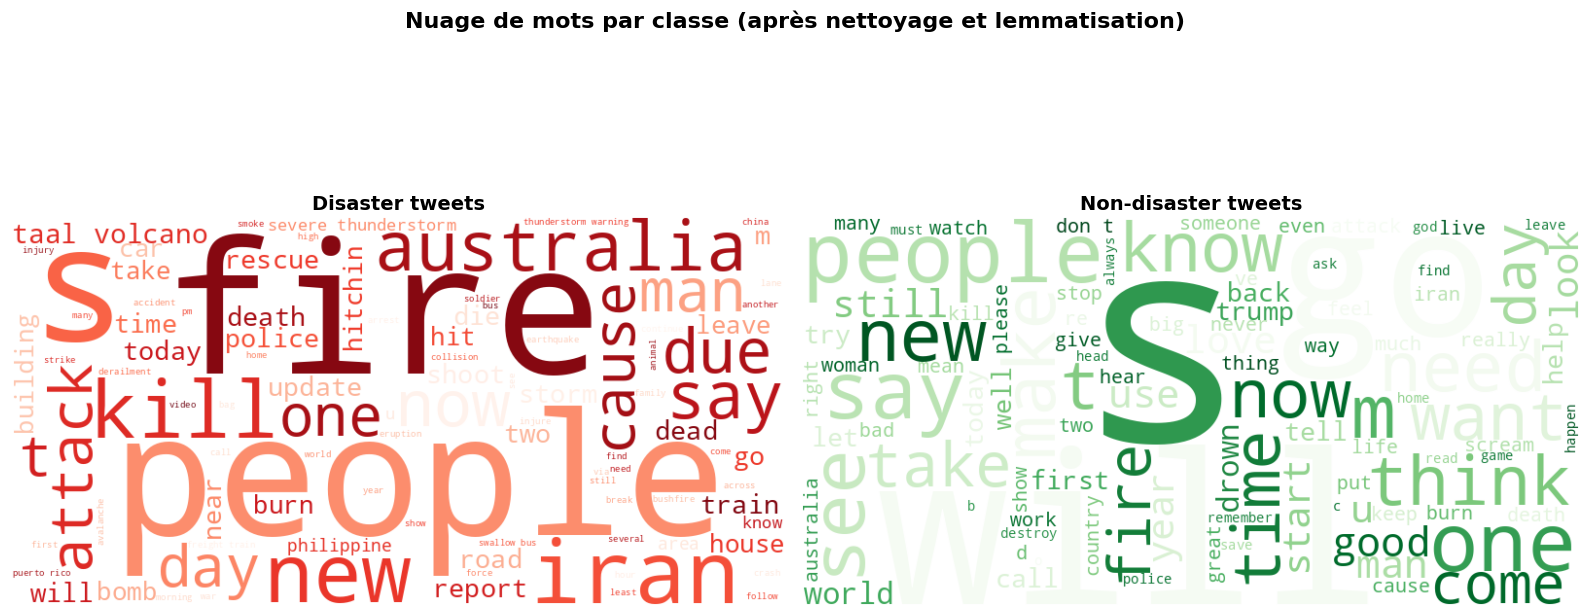

In [55]:
from wordcloud import WordCloud  # génération de nuages de mots (visualisation des mots les plus fréquents)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Texte disaster (target=1)
disaster_text = ' '.join(train[train['target']==1]['text_lemma'].dropna())
wordcloud_disaster = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(disaster_text)

axes[0].imshow(wordcloud_disaster, interpolation='bilinear')
axes[0].set_title('Disaster tweets', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Texte non-disaster (target=0)
non_disaster_text = ' '.join(train[train['target']==0]['text_lemma'].dropna())
wordcloud_non_disaster = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(non_disaster_text)

axes[1].imshow(wordcloud_non_disaster, interpolation='bilinear')
axes[1].set_title('Non-disaster tweets', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Nuage de mots par classe (après nettoyage et lemmatisation)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

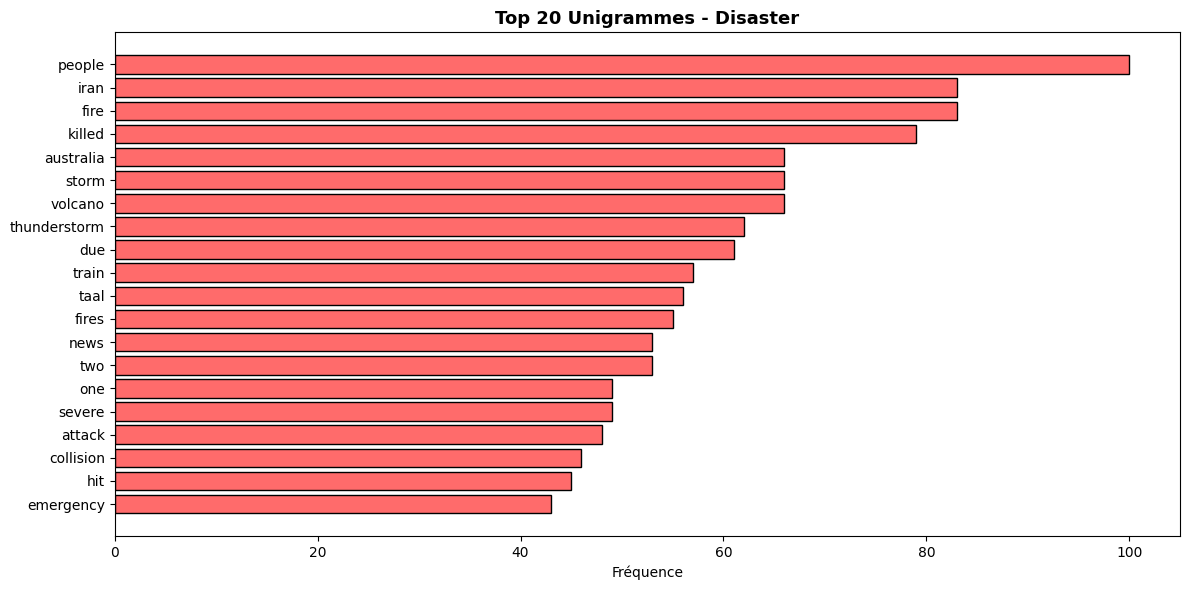

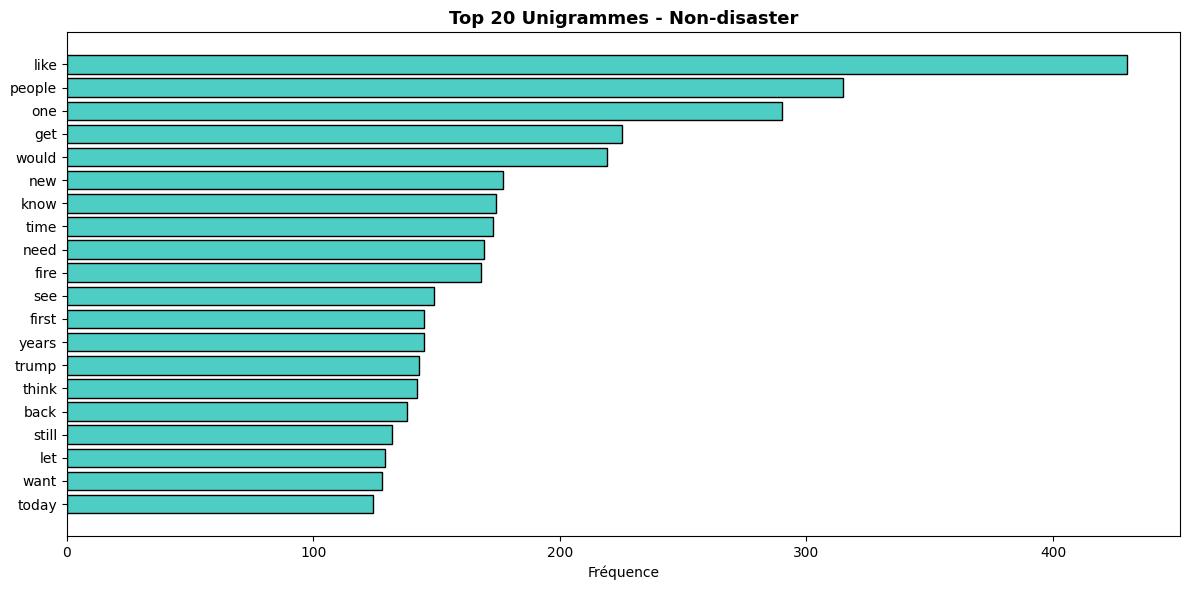

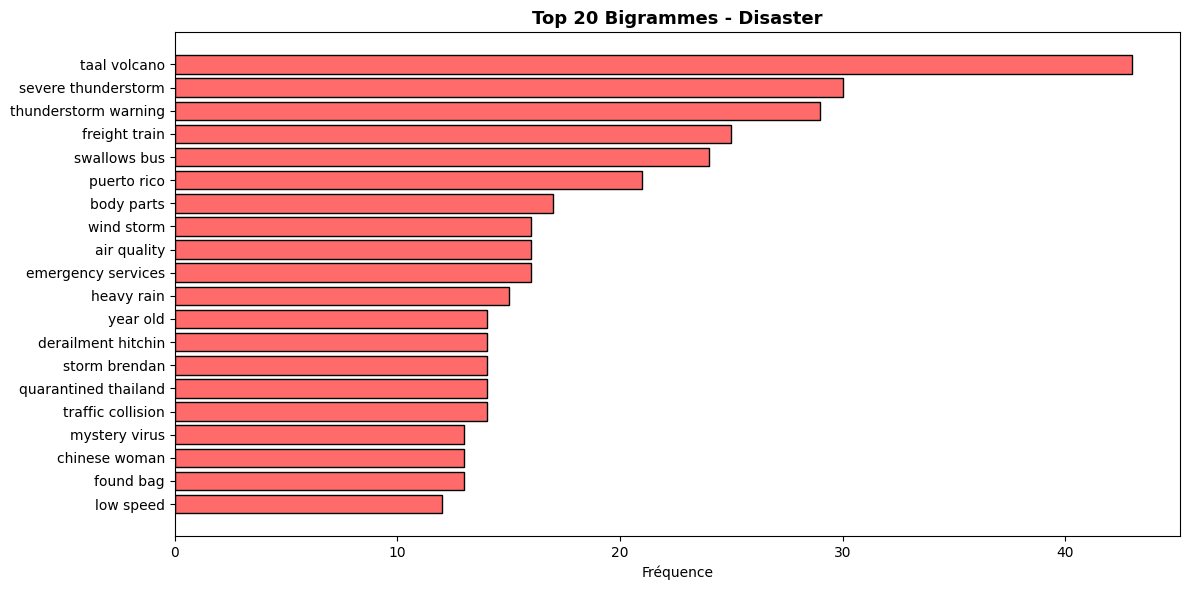

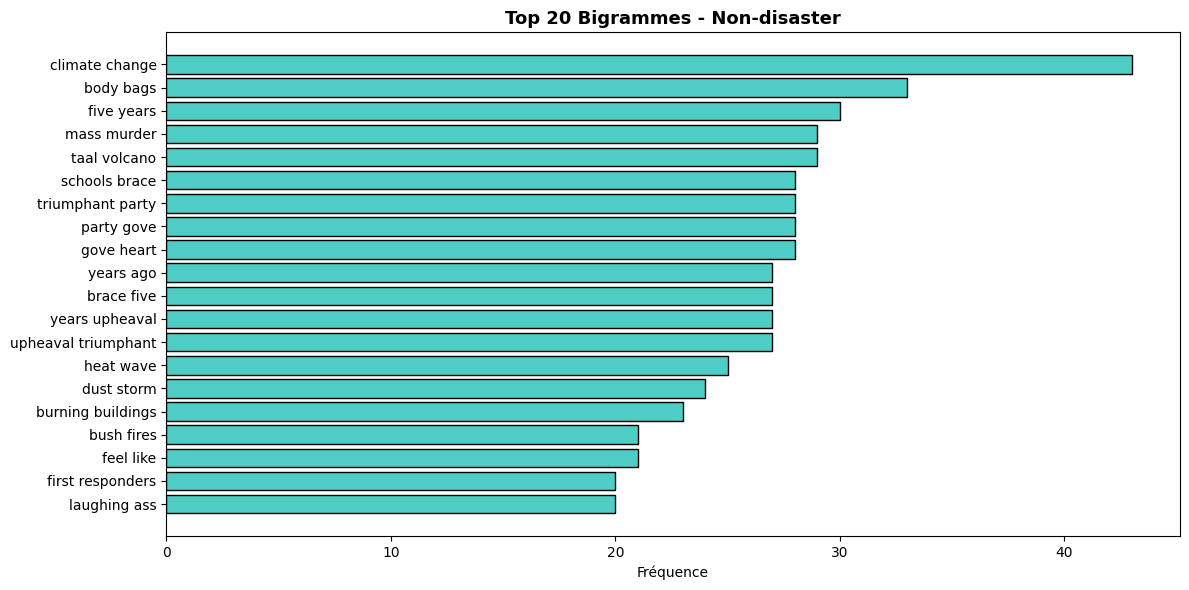

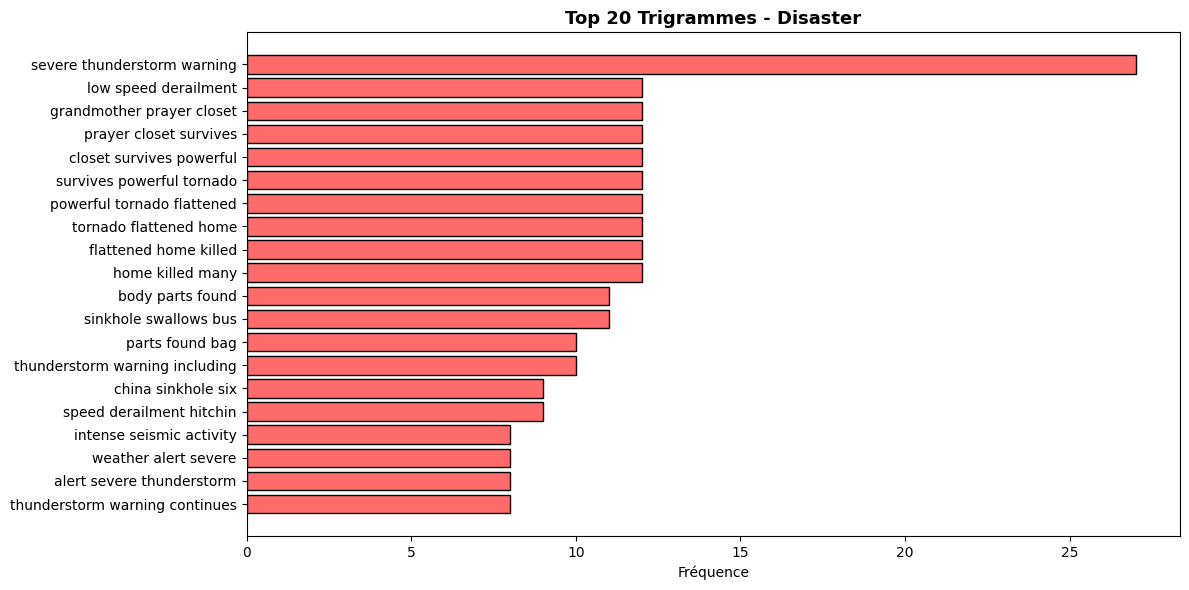

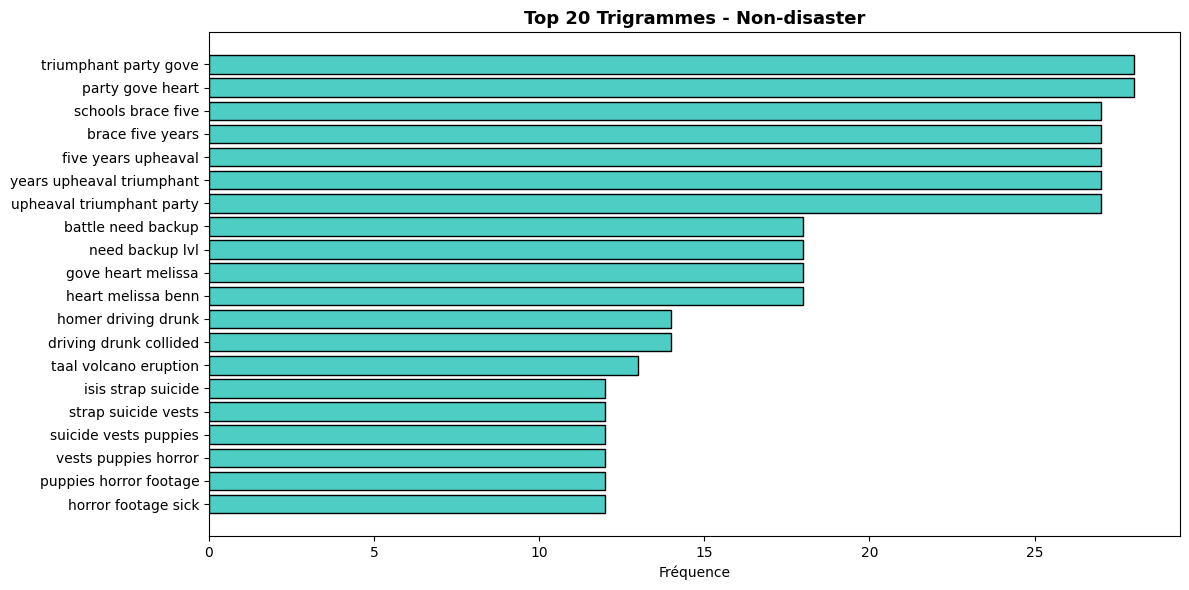

In [56]:
from sklearn.feature_extraction.text import CountVectorizer  # comptage des n-grammes

def plot_ngrams(corpus, n, top_k=20, title='', color='steelblue'):
    """
    Affiche les top_k n-grammes les plus fréquents dans un corpus.
    n=1 : unigrammes | n=2 : bigrammes | n=3 : trigrammes
    """
    vec = CountVectorizer(ngram_range=(n, n), max_features=10000).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    
    words, freqs = zip(*words_freq)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(list(words), list(freqs), color=color, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Fréquence')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
# ── UNIGRAMMES ───────────────────────────────────────────────────────────────
plot_ngrams(train[train['target']==1]['text_tokens'].dropna(),
            n=1, title='Top 20 Unigrammes - Disaster', color='#FF6B6B')

plot_ngrams(train[train['target']==0]['text_tokens'].dropna(),
            n=1, title='Top 20 Unigrammes - Non-disaster', color='#4ECDC4')

# ── BIGRAMMES ────────────────────────────────────────────────────────────────
plot_ngrams(train[train['target']==1]['text_tokens'].dropna(),
            n=2, title='Top 20 Bigrammes - Disaster', color='#FF6B6B')

plot_ngrams(train[train['target']==0]['text_tokens'].dropna(),
            n=2, title='Top 20 Bigrammes - Non-disaster', color='#4ECDC4')

# ── TRIGRAMMES ───────────────────────────────────────────────────────────────
plot_ngrams(train[train['target']==1]['text_tokens'].dropna(),
            n=3, title='Top 20 Trigrammes - Disaster', color='#FF6B6B')

plot_ngrams(train[train['target']==0]['text_tokens'].dropna(),
            n=3, title='Top 20 Trigrammes - Non-disaster', color='#4ECDC4')

In [57]:
# Calcul du taux uniquement sur le train set
keyword_rate = train.groupby('keyword_clean')['target'].mean()

# Application sur train ET test séparément
train['keyword_disaster_rate'] = train['keyword_clean'].map(keyword_rate).fillna(0.5)
test['keyword_disaster_rate']  = test['keyword_clean'].map(keyword_rate).fillna(0.5)

# Vérification
print(f"✅ keyword_disaster_rate créé avec succès")
print(f"Train - valeurs manquantes : {train['keyword_disaster_rate'].isnull().sum()}")
print(f"Test  - valeurs manquantes : {test['keyword_disaster_rate'].isnull().sum()}")
print(f"Train - min: {train['keyword_disaster_rate'].min():.3f} | max: {train['keyword_disaster_rate'].max():.3f} | mean: {train['keyword_disaster_rate'].mean():.3f}")
print(f"Test  - min: {test['keyword_disaster_rate'].min():.3f} | max: {test['keyword_disaster_rate'].max():.3f} | mean: {test['keyword_disaster_rate'].mean():.3f}")

✅ keyword_disaster_rate créé avec succès
Train - valeurs manquantes : 0
Test  - valeurs manquantes : 0
Train - min: 0.000 | max: 0.943 | mean: 0.185
Test  - min: 0.000 | max: 0.943 | mean: 0.189


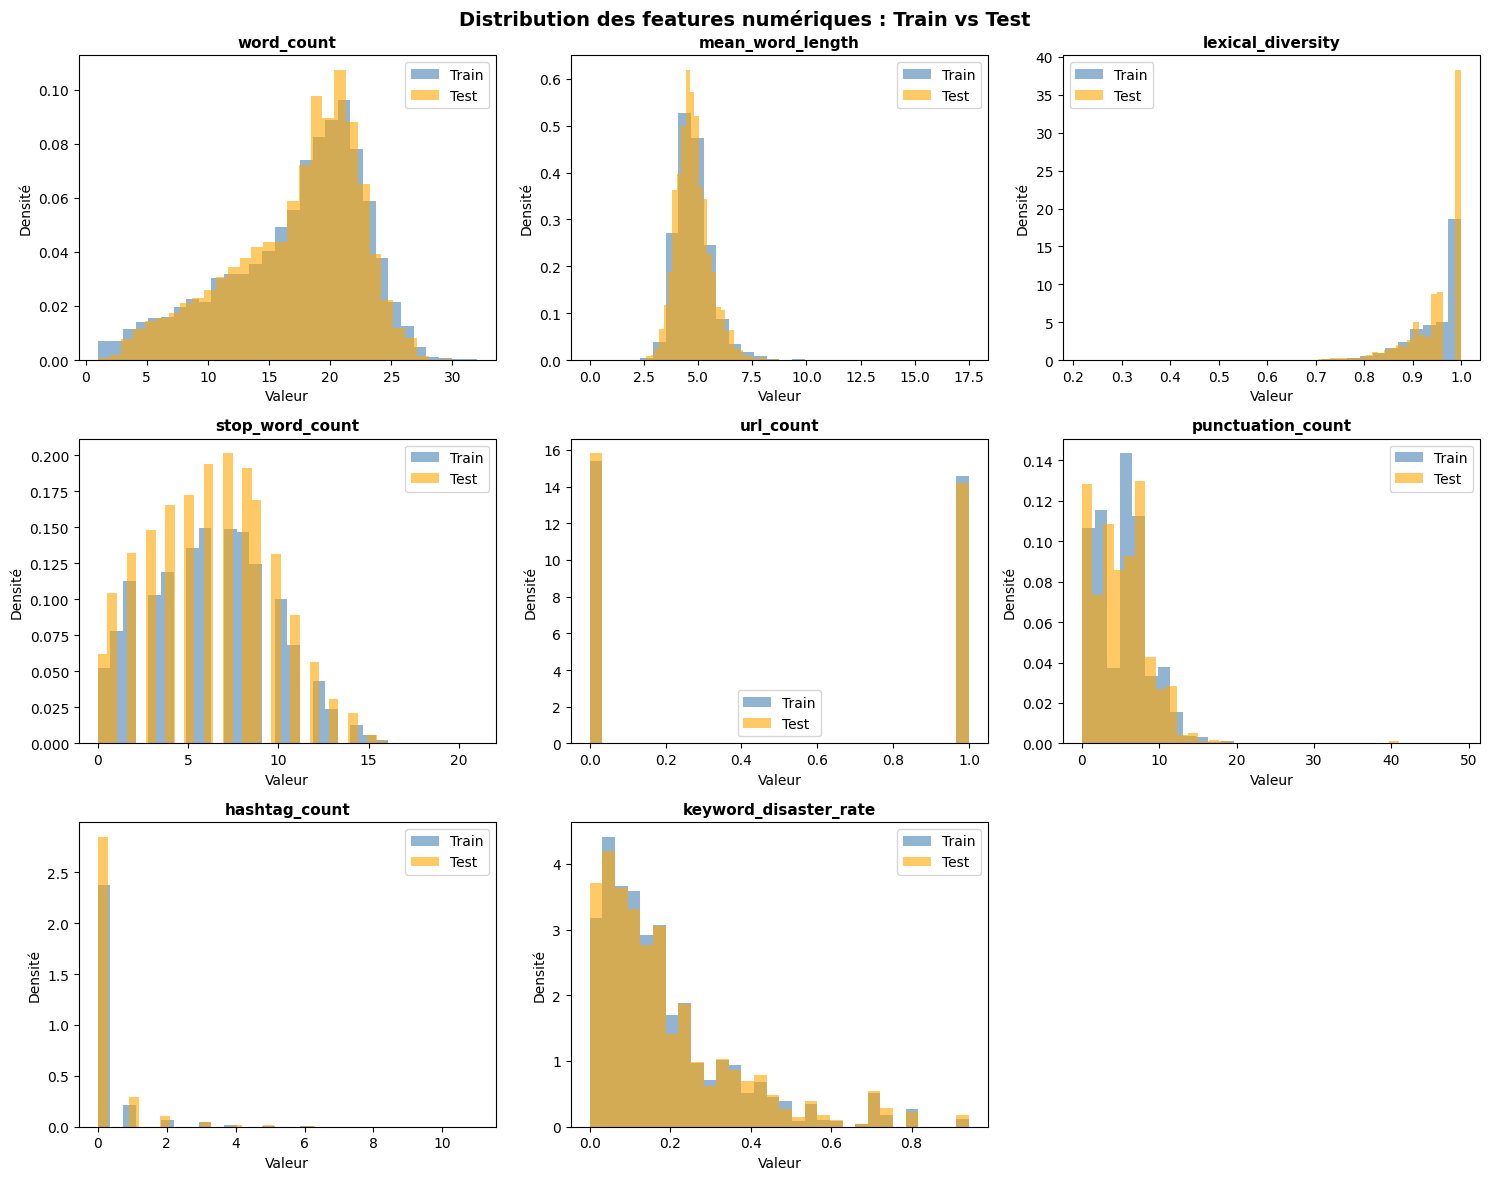

Statistiques descriptives - Train :
       word_count  mean_word_length  lexical_diversity  stop_word_count  \
count     8979.00           8979.00            8979.00          8979.00   
mean        17.21              4.78               0.95             6.24   
std          5.51              0.87               0.06             3.42   
min          1.00              0.00               0.22             0.00   
25%         14.00              4.22               0.92             4.00   
50%         19.00              4.67               0.96             6.00   
75%         21.00              5.20               1.00             9.00   
max         32.00             17.50               1.00            21.00   

       url_count  punctuation_count  hashtag_count  keyword_disaster_rate  
count    8979.00            8979.00        8979.00                8979.00  
mean        0.49               5.21           0.23                   0.18  
std         0.50               3.68           0.73          

In [58]:
# Distribution des features numériques train vs test 
features_num = ['word_count', 'mean_word_length', 'lexical_diversity',
                'stop_word_count', 'url_count', 'punctuation_count',
                'hashtag_count', 'keyword_disaster_rate']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features_num):
    axes[i].hist(train[feature], bins=30, alpha=0.6,
                 color='steelblue', label='Train', density=True)
    axes[i].hist(test[feature],  bins=30, alpha=0.6,
                 color='orange',   label='Test',  density=True)
    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Densité')
    axes[i].legend()

# Supprimer le subplot vide (9 cases pour 8 features)
axes[-1].set_visible(False)

plt.suptitle('Distribution des features numériques : Train vs Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparaison statistique train vs test
print("Statistiques descriptives - Train :")
print(train[features_num].describe().round(2))
print("\nStatistiques descriptives - Test :")
print(test[features_num].describe().round(2))

# 5. Résumé Global de l'Analyse Exploratoire et de la Préparation des Données

---

## 1. Dataset et Variable Cible

Le dataset Disaster Tweets contient 11 370 tweets collectés le 14 janvier 2020.
Après suppression des doublons, le dataset final compte **11 224 observations**
réparties en 5 variables originales : id, keyword, location, text et target.

La tâche est une **classification binaire** : prédire si un tweet décrit une
véritable catastrophe (target=1) ou non (target=0). Le dataset présente un
**déséquilibre modéré** : 81,4% de tweets non-disaster et 18,6% de tweets
disaster. Ce déséquilibre a guidé le choix de la stratification du split train/test pour conserver les proportions.

---

## 2. Variables du Dataset

### Variable cible
* **target** : 1 si le tweet décrit une vraie catastrophe, 0 sinon

### Variables catégorielles
* **keyword** : 219 mots-clés uniques issus des tweets (ex: "earthquake",
  "flood", "fire"). L'analyse du taux de disaster par keyword révèle un
  spectre allant de 0% à 96,3%, confirmant son pouvoir discriminant malgré
  le fait que 91,78% des keywords apparaissent dans les deux classes.
  Le keyword a été nettoyé (suppression des "%20", mise en minuscules) pour
  créer keyword_clean. Un encodage par Target Encoding a également été
  appliqué après le split train/test pour créer keyword_disaster_rate :
  chaque keyword est remplacé par son taux de disaster calculé uniquement
  sur le train set, les keywords absents du train recevant la valeur neutre
  0,5. Cette feature sera utilisée comme variable numérique complémentaire
  dans la modélisation.

* **location** : variable abandonnée en raison d'un taux de valeurs
  manquantes de 30% et de nombreuses valeurs non exploitables ("she/her",
  lieux vagues comme "Earth", "everywhere", "global", incohérences de format).

### Variables textuelles
* **text** : texte brut du tweet (variable principale du projet)
* **text_clean** : texte nettoyé (minuscules, sans URLs, mentions,
  ponctuation, caractères corrompus, contractions expansées)
* **text_tokens** : texte nettoyé sans stopwords (utilisé pour les
  visualisations EDA : nuages de mots, n-grammes)
* **text_lemma** : texte lemmatisé via spaCy  **utilisé pour la
  vectorisation TF-IDF**

---

## 3. Features Numériques Créées

8 features numériques ont été créées pour capturer des caractéristiques
structurelles des tweets, indépendamment de leur contenu sémantique :

| Feature | Description | Calculée sur |
|---|---|---|
| word_count | Nombre de mots | Texte brut |
| mean_word_length | Longueur moyenne des mots | Texte partiellement nettoyé |
| lexical_diversity | Ratio mots uniques / total mots | Texte brut |
| stop_word_count | Nombre de stopwords | Texte brut |
| url_count | Présence d'URL (0/1) | Texte brut |
| punctuation_count | Nombre de signes de ponctuation | Texte brut |
| hashtag_count | Nombre de hashtags (#) | Texte brut |
| keyword_disaster_rate | Taux de disaster par keyword (Target Encoding) | Train set uniquement |

Le test statistique ANOVA F-test confirme que toutes ces features sont
statistiquement significatives (p-value < 0,05), mean_word_length étant
la plus discriminante (score = 199,5). Cependant, leurs corrélations
individuelles avec target restent faibles (max = 0,13), confirmant que
la classification repose principalement sur le contenu sémantique du texte.

---

## 4. Qualité des Données

### Valeurs manquantes
Seule la variable location présente des valeurs manquantes (30,06%),
justifiant son abandon. Les variables text, keyword et target sont complètes.

### Doublons
146 doublons ont été détectés et supprimés (tweets avec text_clean et
keyword identiques), réduisant le dataset de 11 370 à 11 224 observations.
Ces doublons incluaient 142 groupes de 2 occurrences (target cohérent)
et 2 groupes de 3 occurrences (targets différents).

### Valeurs aberrantes
La variable mean_word_length présentait des valeurs aberrantes (max = 69,5)
dues aux URLs et hashtags comptabilisés comme mots par split(). Ces valeurs
ont été corrigées en calculant mean_word_length sur un texte partiellement
nettoyé (sans URLs, hashtags, séparateurs).

---

## 5. Pipeline de Nettoyage

Le nettoyage a été appliqué en deux fonctions complémentaires :

**clean()** corrections cas par cas :
1. Décodage des entités HTML (&amp; → &)
2. Suppression des caractères d'encodage corrompus (\x89Û, å,...)
3. Expansion des contractions (don't → do not, it's → it is,...)
4. Correction des contractions résiduelles (n't → not, 're → are,...)
5. Correction des abréviations, typos et slang (lmao, amirite, traumatised,...)
6. Normalisation des hashtags nommés (BlackLivesMatter → black lives matter)
7. Expansion des acronymes (MH370 → malaysia airlines flight 370)

**basic_clean()** — nettoyage générique :
1. Suppression des emojis (8,2% des tweets, majoritairement figuratifs)
2. Suppression des URLs
3. Suppression des mentions (@)
4. Conservation du mot après suppression du # (#earthquake → earthquake)
5. Suppression de la ponctuation (conservation des chiffres)
6. Suppression des espaces multiples

---

## 6. Tokenisation et Lemmatisation

### Tokenisation
La tokenisation consiste à découper le texte en unités lexicales (tokens).
Dans ce projet, elle sert deux objectifs distincts :

* **Pour les visualisations** (text_tokens) : tokenisation avec suppression
  des stopwords et des tokens < 3 caractères, afin d'obtenir uniquement les
  mots informatifs pour les nuages de mots et les n-grammes.

* **Pour la vectorisation TF-IDF** : la tokenisation est gérée automatiquement
  par TfidfVectorizer ; il n'est pas nécessaire de tokeniser manuellement
  avant de passer le texte au vectoriseur.

### Lemmatisation
La lemmatisation réduit chaque mot à sa forme canonique (lemme) en tenant
compte de sa nature grammaticale (nom, verbe, adjectif, adverbe) :

* "fires", "fired", "firing" → "fire"
* "casualties" → "casualty"
* "buildings" → "building"
* "running" (verbe) → "run"

Réalisée via spaCy (en_core_web_sm), elle permet de réduire la
dimensionnalité du vocabulaire TF-IDF en regroupant les variantes d'un
même mot sous une seule feature, améliorant ainsi la généralisation du
modèle sur de nouveaux tweets. Le texte lemmatisé est stocké dans
text_lemma et sera utilisé pour la vectorisation TF-IDF.

---

## 7. Split Train/Test

Le dataset a été divisé en :
* **Train** : 9 096 tweets (80%)
* **Test** : 2 274 tweets (20%)

La stratification (`stratify=target`) garantit que les proportions
disaster/non-disaster sont conservées dans les deux ensembles, ce qui
est essentiel étant donné le déséquilibre modéré (81,4% / 18,6%).
La comparaison des statistiques descriptives entre train et test confirme
une distribution homogène des features numériques entre les deux ensembles,
validant la qualité du split.

---

## 8. Observations Clés

* Les tweets disaster utilisent un vocabulaire plus **factuel, technique
  et homogène** (mean_word_length plus élevée, lexical_diversity plus
  concentrée, moins de stopwords)
* Les tweets non-disaster sont plus **expressifs et conversationnels**
  (plus de stopwords, plus de variabilité, présence d'emojis plus fréquente)
* Les features numériques ont un pouvoir discriminant individuel faible
  (corrélation max = 0,13 avec target) ; c'est leur **combinaison avec
  la vectorisation TF-IDF** du texte qui sera déterminante pour la
  classification
* Le keyword présente un pouvoir discriminant notable (taux disaster de
  0% à 96,3%) et a été encodé via Target Encoding (technique qui remplace
  chaque catégorie par la moyenne de la variable cible pour ce groupe, ici :  la proportion de tweets disaster par keyword), créant ainsi la
  feature keyword_disaster_rate, calculée uniquement sur le train set
  pour éviter tout data leakage.

# 6. Sauvegarde

In [59]:
# Supprimer les colonnes temporaires avant export
train = train.drop(columns=['clean_word_count', 'tokens_lost'])

# Vérification
print(f"Train : {train.shape}")  # doit afficher 17
print(f"Test  : {test.shape}")   # 17

# Re-export
train.to_csv('/kaggle/working/train_cleaned.csv', index=False)
test.to_csv('/kaggle/working/test_cleaned.csv',   index=False)

Train : (8979, 17)
Test  : (2245, 17)


In [60]:
# Export des datasets nettoyés pour la modélisation
train.to_csv('/kaggle/working/train_cleaned.csv', index=False)
test.to_csv('/kaggle/working/test_cleaned.csv',   index=False)

print('✅ Fichiers train_cleaned.csv et test_cleaned.csv sauvegardés !')
print(f'   train : {train.shape}')
print(f'   test  : {test.shape}')
print(f'   colonnes : {list(train.columns)}')

✅ Fichiers train_cleaned.csv et test_cleaned.csv sauvegardés !
   train : (8979, 17)
   test  : (2245, 17)
   colonnes : ['id', 'keyword', 'location', 'text', 'target', 'word_count', 'mean_word_length', 'lexical_diversity', 'stop_word_count', 'url_count', 'punctuation_count', 'hashtag_count', 'text_clean', 'keyword_clean', 'text_tokens', 'text_lemma', 'keyword_disaster_rate']


Les datasets nettoyés ont été sauvegardés avec succès :

* **Train** : 9 096 tweets × 17 colonnes
* **Test**  : 2 274 tweets × 17 colonnes

Ces datasets contiennent les variables originales (id, keyword, location, 
text, target), les features numériques créées : 
* word_count,
* mean_word_length, 
* lexical_diversity,
* stop_word_count,
* url_count,
* punctuation_count,
* hashtag_count, 
keyword_disaster_rate,
 ainsi que les versions nettoyées du texte (text_clean, text_lemma, text_tokens) et du keyword (keyword_clean), prêts à être utilisés pour la modélisation.